# Investigación sobre la experiencia museística

## Por Jesús Eduardo Oliva Abarca

## Objetivos
* Obtener estimaciones de la oferta y demanda museística por estado en México
* Identificar los aspectos y/o atributos de la experiencia de visitantes a museos a través de sus opiniones en *Google*
* Examinar las preferencias de visitantes a museos mediante el análisis de sentimientos basado en aspectos
* Definir perfiles de visitantes con base en sus preferencias analizadas previamente
* Desarrollar estrategia(s) para mejorar la experiencia museística y el incremento de visitantes mediante Aprendizaje Automático

https://github.com/misha345a/E-commerce_Reviews_Classifier/blob/main/ASBA.ipynb

## Exploración de datos abiertos de museos en México

Obtención de datos de museos por estados, a través de la página del Sistema de Información Cultural de México. Con esto, se pretende seleccionar los museos más representativos por estado, para, posteriormente, llevar a cabo el "raspado de red" de las opiniones en *Google*. Se asume que los museos que cuentan con página web tienen mayor difusión, por lo que se conforma un conjunto de datos con éstos, para después desarrollar un programa que automatice la recogida de datos en *Google*. **Corregir: ya no se trabaja con tal presupuesto**

In [1]:
import time
import numpy as np
import pandas as pd
import requests as rq
import dataframe_image as dfi
import matplotlib.pyplot as plt

In [39]:
url = 'https://sic.cultura.gob.mx/opendata/d/0_museo_directorio.json'
respuesta = rq.get(url= url)

In [40]:
datos_museos = respuesta.json()
print(datos_museos[0])
print(len(datos_museos))

{'museo_id': 1046, 'museo_tematica_n1': 'Arte', 'museo_nombre': 'Museo José Guadalupe Posada', 'museo_fecha_fundacion': '1972-09-16', 'museo_adscripcion': 'Instituto Cultural de Aguascalientes (ICA)', 'museo_tipo_de_propiedad': 'público', 'museo_calle_numero': 'Jardín del Encino s/n lado Nte.', 'museo_colonia': 'Barrio del Encino', 'museo_cp': '20240', 'museo_telefono1': '(449) 915 45 56', 'pagina_web': '', 'pagina_web2': '', 'email': 'museoposada@gmail.com', 'twitter': '', 'gmaps_latitud': 21.87534, 'gmaps_longitud': -102.29298, 'estado_id': 1, 'municipio_id': 1, 'localidad_id': 1, 'nom_ent': 'Aguascalientes', 'nom_mun': 'Aguascalientes', 'nom_loc': 'Aguascalientes', 'link_sic': 'http://sic.gob.mx/ficha.php?table=museo&table_id=1046', 'fecha_mod': '2021-05-24T03:32:04-05:00'}
1427


In [41]:
nombre = []
tematica = []
adscripcion = []
pagina_web = []
entidad = []
municipio = []

In [42]:
for museo in datos_museos:
    #if museo['pagina_web'] != '':
        #print(museo['museo_nombre'], '\n', museo['museo_tematica_n1'], museo['museo_adscripcion'], '\n', museo['nom_ent'], 
                #'\n', museo['nom_mun'], '\n', museo['pagina_web'])
    nombre.append(museo['museo_nombre'])
    tematica.append(museo['museo_tematica_n1'])
    adscripcion.append(museo['museo_adscripcion'])
    pagina_web.append(museo['pagina_web'])
    entidad.append(museo['nom_ent'])
    municipio.append(museo['nom_mun'])

In [43]:
lista_datos_museos = list(zip(nombre, tematica, adscripcion, pagina_web, entidad, municipio))

In [44]:
df_museos = pd.DataFrame(data= lista_datos_museos, columns= ['Nombre', 'Temática', 'Adscripción', 'Página web','Entidad', 'Municipio'])
df_museos

,Nombre,Temática,Adscripción,Página web,Entidad,Municipio
0,Museo José Guadalupe Posada,Arte,Instituto Cultural de Aguascalientes (ICA),,Aguascalientes,Aguascalientes
1,Museo de Sitio los Arquitos,Historia,Instituto Cultural de Aguascalientes/Centro Cu...,https://www.aguascalientes.gob.mx/temas/cultura/,Aguascalientes,Aguascalientes
2,Museo de la Fauna,Ciencia y tecnología,Secretaría del Medio Ambiente Estatal/CEAR Rod...,http://www.aguascalientes.gob.mx/ssmaa/Areasve...,Aguascalientes,Aguascalientes
3,Museo Ferrocarrilero,Historia,Instituto Cultural de Aguascalientes (ICA)/Dir...,https://museosygalerias.com/conoce-mas/artist-1/,Aguascalientes,Aguascalientes
4,Museo Regional de Historia de Aguascalientes,Historia,Secretaría de Cultura/INAH,http://www.inah.gob.mx/red-de-museos/235-museo...,Aguascalientes,Aguascalientes
...,...,...,...,...,...,...
1422,Sala Despacho Antonio Aguilar Barraza,,Instituto Zacatecano de Cultura Ramón López Ve...,https://www.facebook.com/CiudadeladelArteZacat...,Zacatecas,Zacatecas
1423,Museo de la Industria de Reuniones,,Gobierno del Estado de Zacatecas/Palacio de Co...,https://zacatecasmeetings.com/mir/,Zacatecas,Zacatecas
1424,Museo Rafael Coronel,Arte,Instituto Zacatecano de Cultura Ramón López Ve...,,Zacatecas,Zacatecas
1425,Museo Zacatecano,Arte,Instituto Zacatecano de Cultura Ramón López Ve...,,Zacatecas,Zacatecas


In [45]:
df_museos.to_csv('Datos/datos_sic_museos.csv')

In [48]:
df_museos[df_museos['Entidad'].str.contains('Nuevo León')]
#df_museos['Entidad'].str.contains('Nuevo León').sum()

,Nombre,Temática,Adscripción,Página web,Entidad,Municipio
896,Museo de Antropología e Historia de Allende,Historia,Ayuntamiento de Allende,,Nuevo León,Allende
897,Museo Profr. Moisés Sáenz Garza,Historia,Casa de Cultura/Ayuntamiento de Apodaca,,Nuevo León,Apodaca
898,Museo de la Memoria Viva,,"Mundo Sustentable, A.C.",,Nuevo León,Bustamante
899,Museo de las Cosas Simples,,Fundación Mundo Sustentable A.C.,,Nuevo León,Bustamante
900,Museo General Ponciano Cisneros Quiroga,Historia,Ayuntamiento de Ciénega de Flores,,Nuevo León,Ciénega de Flores
901,Museo El Ojo,Arte,Particular,,Nuevo León,García
902,Museo El Centenario,Historia,Ayuntamiento de San Pedro Garza García/Secreta...,,Nuevo León,San Pedro Garza García
903,Museo de General Bravo,Especializado,Ayuntamiento de General Bravo,,Nuevo León,General Bravo
904,Museo Histórico de Escobedo,Historia,Ayuntamiento de Escobedo,,Nuevo León,General Escobedo
905,Museo Municipal de General Zaragoza,,Ayuntamiento de General Zaragoza,,Nuevo León,General Zaragoza


In [3]:
df = pd.read_csv('Datos/datos_sic_museos.csv', index_col= 0)
df

,Nombre,Temática,Adscripción,Página web,Entidad,Municipio
0,Museo José Guadalupe Posada,Arte,Instituto Cultural de Aguascalientes (ICA),NaN,Aguascalientes,Aguascalientes
1,Museo de Sitio los Arquitos,Historia,Instituto Cultural de Aguascalientes/Centro Cu...,https://www.aguascalientes.gob.mx/temas/cultura/,Aguascalientes,Aguascalientes
2,Museo de la Fauna,Ciencia y tecnología,Secretaría del Medio Ambiente Estatal/CEAR Rod...,http://www.aguascalientes.gob.mx/ssmaa/Areasve...,Aguascalientes,Aguascalientes
3,Museo Ferrocarrilero,Historia,Instituto Cultural de Aguascalientes (ICA)/Dir...,https://museosygalerias.com/conoce-mas/artist-1/,Aguascalientes,Aguascalientes
4,Museo Regional de Historia de Aguascalientes,Historia,Secretaría de Cultura/INAH,http://www.inah.gob.mx/red-de-museos/235-museo...,Aguascalientes,Aguascalientes
...,...,...,...,...,...,...
1422,Sala Despacho Antonio Aguilar Barraza,NaN,Instituto Zacatecano de Cultura Ramón López Ve...,https://www.facebook.com/CiudadeladelArteZacat...,Zacatecas,Zacatecas
1423,Museo de la Industria de Reuniones,NaN,Gobierno del Estado de Zacatecas/Palacio de Co...,https://zacatecasmeetings.com/mir/,Zacatecas,Zacatecas
1424,Museo Rafael Coronel,Arte,Instituto Zacatecano de Cultura Ramón López Ve...,NaN,Zacatecas,Zacatecas
1425,Museo Zacatecano,Arte,Instituto Zacatecano de Cultura Ramón López Ve...,NaN,Zacatecas,Zacatecas


In [6]:
dfi.export(df.head(n= 10).style.background_gradient(), 'Figuras/Fig_uno.png')

c:\users\jedua\documents\i+d+i\i+d+i\lib\site-packages\dataframe_image\_pandas_accessor.py:69: FutureWarning: this method is deprecated in favour of `Styler.to_html()`
  html = '<div>' + obj.render() + '</div>'


## Extracción automatizada de opiniones 
Empleando el conjunto de datos obtenido en la sección anterior, se desarrolla aquí una serie de funciones con las cuales se automatice la recolección de opiniones de usuarios de *Google*. Se espera recabar información diversificada y suficiente para conformar un conjunto de datos con opiniones y valoraciones, a través del cual se puedan identificar "aspectos" que posibiliten una categorización más detallada de las preferencias de visitantes a museos nacionales.

In [2]:
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.common.exceptions import NoSuchElementException

In [3]:
def comprobacion_opiniones(ruta_df):
    lista_puntajes = []
    lista_cantidad_comentarios = []
    navegador = webdriver.Chrome()
    navegador.get('https://www.google.com.mx/')
    df = pd.read_csv(ruta_df, index_col= 0)
    for i, j in zip(df['Nombre'], df['Entidad']):
        navegador.find_element(by= 'name', value= 'q').send_keys(i + ' ' + j)
        time.sleep(2)
        #navegador.find_element_by_class_name('wM6W7d').click()
        navegador.find_element(by= 'name', value= 'q').send_keys(Keys.ENTER)
        time.sleep(3)
        try:
            navegador.find_element_by_class_name('Aq14fc')
            lista_puntajes.append(float(navegador.find_element_by_class_name('Aq14fc').text))
            navegador.find_element_by_css_selector('.hqzQac')
            lista_cantidad_comentarios.append(navegador.find_element_by_css_selector('.hqzQac').text)
            #print(navegador.find_element_by_css_selector('.hqzQac').text)
            navegador.back()
        except NoSuchElementException:
            lista_puntajes.append('NaN')
            lista_cantidad_comentarios.append('0')
            #print('No se encontró')
            navegador.back()
            pass
    #print(lista_cantidad_comentarios)
    df['Puntaje'] = lista_puntajes
    lista_cantidades_limpia = []
    for i in lista_cantidad_comentarios:
        i = i.replace(',', '')
        i = i.replace('comentario de Google', '0')
        i = i.replace(' comentarios de Google', '')
        lista_cantidades_limpia.append(int(i))
    df['Cantidad de comentarios'] = lista_cantidades_limpia
    navegador.close()
    return df

In [8]:
df_resultado = comprobacion_opiniones('DatosAnálisisSentimientosAspectos/datos_sic_museos.csv')

C:\Users\jedua\AppData\Local\Temp\ipykernel_10512\3067787977.py:14: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_class_name('Aq14fc')
C:\Users\jedua\AppData\Local\Temp\ipykernel_10512\3067787977.py:15: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  lista_puntajes.append(float(navegador.find_element_by_class_name('Aq14fc').text))
C:\Users\jedua\AppData\Local\Temp\ipykernel_10512\3067787977.py:16: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac')
C:\Users\jedua\AppData\Local\Temp\ipykernel_10512\3067787977.py:17: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  lista_cantidad_comentarios.append(navegador.find_element_by_css_selector('.hqzQac').text)


In [7]:
df_resultado = pd.read_csv('Datos/datos_museos_num_comentarios.csv', index_col= 0)
df_resultado

,Nombre,Temática,Adscripción,Página web,Entidad,Municipio,Puntaje,Cantidad de comentarios
0,Museo José Guadalupe Posada,Arte,Instituto Cultural de Aguascalientes (ICA),NaN,Aguascalientes,Aguascalientes,4.7,1276
1,Museo de Sitio los Arquitos,Historia,Instituto Cultural de Aguascalientes/Centro Cu...,https://www.aguascalientes.gob.mx/temas/cultura/,Aguascalientes,Aguascalientes,NaN,0
2,Museo de la Fauna,Ciencia y tecnología,Secretaría del Medio Ambiente Estatal/CEAR Rod...,http://www.aguascalientes.gob.mx/ssmaa/Areasve...,Aguascalientes,Aguascalientes,NaN,0
3,Museo Ferrocarrilero,Historia,Instituto Cultural de Aguascalientes (ICA)/Dir...,https://museosygalerias.com/conoce-mas/artist-1/,Aguascalientes,Aguascalientes,4.7,1589
4,Museo Regional de Historia de Aguascalientes,Historia,Secretaría de Cultura/INAH,http://www.inah.gob.mx/red-de-museos/235-museo...,Aguascalientes,Aguascalientes,4.5,890
...,...,...,...,...,...,...,...,...
1422,Sala Despacho Antonio Aguilar Barraza,NaN,Instituto Zacatecano de Cultura Ramón López Ve...,https://www.facebook.com/CiudadeladelArteZacat...,Zacatecas,Zacatecas,3.9,7
1423,Museo de la Industria de Reuniones,NaN,Gobierno del Estado de Zacatecas/Palacio de Co...,https://zacatecasmeetings.com/mir/,Zacatecas,Zacatecas,NaN,0
1424,Museo Rafael Coronel,Arte,Instituto Zacatecano de Cultura Ramón López Ve...,NaN,Zacatecas,Zacatecas,4.7,5050
1425,Museo Zacatecano,Arte,Instituto Zacatecano de Cultura Ramón López Ve...,NaN,Zacatecas,Zacatecas,4.8,833


In [4]:
#df_resultado.groupby(by= 'Temática').count()

In [17]:
#df_resultado['Temática'] = df_resultado['Temática'].str.replace('TND', 'Temática no determinada')

In [9]:
dfi.export(df_resultado.groupby(by= 'Temática').count(), 'Figuras/Fig_dos.png')
df_resultado.groupby(by= 'Temática').count()

,Nombre,Adscripción,Página web,Entidad,Municipio,Puntaje,Cantidad de comentarios
Temática,,,,,,,
Antropología,83,80,26,83,83,46,83
Arqueología,246,245,121,246,246,166,246
Arte,278,271,158,278,278,243,278
Arte Alternativo,1,1,1,1,1,1,1
Ciencia y tecnología,149,146,85,149,149,120,149
Especializado,65,62,33,65,65,50,65
Historia,394,385,141,394,394,272,394
Temática no determinada,38,34,6,38,38,17,38


In [19]:
#df_resultado.to_csv('DatosAnálisisSentimientosAspectos/datos_museos_num_comentarios.csv')

In [11]:
dfi.export(df_resultado.groupby(by= 'Temática' ).get_group('Antropología').sort_values(by= 'Cantidad de comentarios', 
                                                                                       ascending = False).head(10), 'Figuras/Fig_tres.png')
df_resultado.groupby(by= 'Temática' ).get_group('Antropología').sort_values(by= 'Cantidad de comentarios', ascending = False)

,Nombre,Temática,Adscripción,Página web,Entidad,Municipio,Puntaje,Cantidad de comentarios
413,Museo Nacional de Antropología (MNA),Antropología,Secretaría de Cultura/INAH,https://www.mna.inah.gob.mx/,Ciudad de México,Miguel Hidalgo,4.8,58049
793,Museo de la Tierra Caliente,Antropología,"Centro de Cultura y Desarrollo, A.C.",https://www.facebook.com/Museo-de-la-Tierra-Ca...,Michoacán de Ocampo,Apatzingán,4.8,10240
326,Museo del Estanquillo,Antropología,Fideicomiso Museo del Estanquillo,http://www.museodelestanquillo.cdmx.gob.mx/elm...,Ciudad de México,Cuauhtémoc,4.6,9718
394,Palacio de la Escuela de Medicina,Antropología,UNAM/Facultad de Medicina,NaN,Ciudad de México,Cuauhtémoc,4.6,7378
859,"Museo Regional Cuauhnáhuac, Palacio de Cortés",Antropología,Secretaría de Cultura/INAH,http://www.inah.gob.mx/es/red-de-museos/249-mu...,Morelos,Cuernavaca,4.4,2992
...,...,...,...,...,...,...,...,...
997,Museo Regional de Cuetzalan Emma Flores de Mor...,Antropología,Ayuntamiento de Cuetzalan,NaN,Puebla,Cuetzalan del Progreso,NaN,0
1047,Museo Comunitario Hueyotli,Antropología,Junta Hueyotli,http://turismoenpuebla.com/portal/art123_Museo...,Puebla,Santo Tomás Hueyotlipan,NaN,0
158,Museo Comunitario Raíces de mi Pueblo,Antropología,"Raíces de mi Pueblo Chyks Kungny, A.C.",NaN,Chiapas,Copainalá,NaN,0
1118,Museo Comunitario Ya Nfadi Ya Ñohño (Los conoc...,Antropología,Unión Estatal de Museos Comunitarios del Estad...,NaN,Querétaro,Tolimán,NaN,0


In [21]:
df_resultado[df_resultado.duplicated()]

,Nombre,Temática,Adscripción,Página web,Entidad,Municipio,Puntaje,Cantidad de comentarios


In [7]:
def recoleccion_comentarios(nombre_museo, num_it):
    df = pd.DataFrame()
    lista_comentarios = []
    #lista_antiguedad = []
    numero = num_it
    navegador = webdriver.Chrome()
    navegador.get('https://www.google.com.mx/')
    navegador.find_element(by= 'name', value= 'q').send_keys(nombre_museo)
    time.sleep(1)
    navegador.find_element(by= 'name', value= 'q').send_keys(Keys.ENTER)
    navegador.find_element_by_css_selector('.hqzQac').click()
    time.sleep(2)
    opiniones = navegador.find_element_by_class_name('review-dialog-list')
    while numero > 0:
        time.sleep(1)
        navegador.execute_script("arguments[0].scrollTop = arguments[0].scrollHeight", opiniones)
        numero -= 1
    for i in navegador.find_elements_by_class_name('review-more-link'):
        time.sleep(1)
        i.click()
    for elemento in navegador.find_elements_by_class_name('Jtu6Td'):
        time.sleep(1)
        lista_comentarios.append(elemento.text)
    #for i in navegador.find_elements_by_class_name('PuaHbe'):
        #lista_antiguedad.append(i.text)
    df['Comentario'] = lista_comentarios
    #df['Antigüedad'] = lista_antiguedad
    navegador.close()
    return df

In [23]:
df_comentarios_antropologia_00 = recoleccion_comentarios(nombre_museo= 'Museo Nacional de Antropología (MNA)', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:24: Deprecat

In [40]:
df_comentarios_antropologia_00.drop(columns= 'Antigüedad', inplace= True)
df_comentarios_antropologia_00

,Comentario
0,Excelente lugar lleno de conocimiento y cultur...
1,"Extraordinario, sin duda se gana ser el museo ..."
2,"Un museo lleno de historia, muy bello. Se expo..."
3,El lugar indicado para conocer sobre nuestra c...
4,Necesitas de más de dos horas para recorrer la...
...,...
1005,Si te interesa saber un poco sobre la hermosa ...
1006,Desde hace tiempo quería conocer este museo re...
1007,Uno de los mejores museos de Mexico
1008,Es muy bueno tiene la historia de México desde...


In [26]:
df_comentarios_antropologia_01 = recoleccion_comentarios(nombre_museo= 'Museo de la Tierra Caliente Michoacán de Ocampo', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:24: Deprecat

In [41]:
df_comentarios_antropologia_01.drop(columns= 'Antigüedad', inplace= True)
df_comentarios_antropologia_01

,Comentario
0,Excelente museo para conocer sobre la historia...
1,"Excelente, sólo sugiero que se puedan poner gu..."
2,Un museo bastante interesante y extenso que ab...
3,Excelente museo. Se conserva muy bien . Siempr...
4,Es muy buen museo y hay cosas muy interesantes...
...,...
995,Un museo excelente. Se requiere de tiempo para...
996,Un lugar lleno de historia i muy hermozo vale ...
997,Excelente muy entretenido . Además en algunas ...
998,La exposición permanente es simple pero repres...


In [34]:
df_comentarios_antropologia_02 = recoleccion_comentarios(nombre_museo= 'Museo Regional de Guadalajara', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:24: Deprecat

In [43]:
df_comentarios_antropologia_02.drop(columns= 'Antigüedad', inplace= True)
df_comentarios_antropologia_02

,Comentario
0,El museo abre de miercoles a sabado de 11:30 a...
1,Es un lugar muy interesante y lleno de objetos...
2,Un pequeño pero interesante museo con obras hi...
3,"Amplia colección de fosiles de dinosaurios, tr..."
4,Un museo muy interesante con todas las exhibic...
...,...
1005,
1006,
1007,
1008,


In [32]:
df_comentarios_antropologia_03 = recoleccion_comentarios(nombre_museo= 'Museo Regional Cuauhnáhuac, Palacio de Cortés', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\961028165.py:24: Deprecat

In [44]:
df_comentarios_antropologia_03.drop(columns= 'Antigüedad', inplace= True)
df_comentarios_antropologia_03

,Comentario
0,El palacio de Cortés es uno de los lugares que...
1,"Desafortunadamente esta en remodelacion, por t..."
2,"El Palacio de Cortés, Cuernavaca, Morelos\n\nL..."
3,Me imagino que si debe ser genial. Sin embargo...
4,Esta cerrado por rehabilitación desde el seísm...
...,...
1005,Lujares muy bonitos
1006,El trato del personal es muy bueno
1007,Buen lugar turístico
1008,Hermoso sitio.


In [38]:
df_comentarios_antropologia_04 = recoleccion_comentarios(nombre_museo= 'Museo Na-Bolom (Casa del Jaguar)', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [39]:
df_comentarios_antropologia_04

,Comentario
0,Me quedé con ganas de ver un poco más ya que ...
1,Entrar al museo tiene un precio de $70 por per...
2,"Muy bonito museo , no olvides mirar el vídeo e..."
3,Un lugar indispensable de paso. Aparte de todo...
4,"Lo peor de lo peor, no tenían cobertores extra..."
...,...
764,(Traducción de Google) Fascinante y educativo....
765,(Traducción de Google) súper\n\n(Original)\nsuper
766,(Traducción de Google) Está bien.....\n\n(Orig...
767,(Traducción de Google) Encantador\n\n(Original...


In [52]:
df_comentarios_antropologia = pd.concat([df_comentarios_antropologia_00, df_comentarios_antropologia_01, 
                                        df_comentarios_antropologia_02, df_comentarios_antropologia_03, df_comentarios_antropologia_04])
df_comentarios_antropologia.reset_index(inplace= True)
df_comentarios_antropologia.drop(columns= 'index', inplace= True)
df_comentarios_antropologia

,Comentario
0,Excelente lugar lleno de conocimiento y cultur...
1,"Extraordinario, sin duda se gana ser el museo ..."
2,"Un museo lleno de historia, muy bello. Se expo..."
3,El lugar indicado para conocer sobre nuestra c...
4,Necesitas de más de dos horas para recorrer la...
...,...
4794,(Traducción de Google) Fascinante y educativo....
4795,(Traducción de Google) súper\n\n(Original)\nsuper
4796,(Traducción de Google) Está bien.....\n\n(Orig...
4797,(Traducción de Google) Encantador\n\n(Original...


In [53]:
df_comentarios_antropologia.to_csv('Datos/comentarios_museos_antropología.csv')

In [12]:
dfi.export(df_resultado.groupby(by= 'Temática' ).get_group('Arqueología').sort_values(by= 'Cantidad de comentarios', 
                                                                                      ascending = False).head(10), 'Figuras/Fig_cuatro.png')
df_resultado.groupby(by= 'Temática' ).get_group('Arqueología').sort_values(by= 'Cantidad de comentarios', ascending = False).head(10)

,Nombre,Temática,Adscripción,Página web,Entidad,Municipio,Puntaje,Cantidad de comentarios
353,Museo de Sitio del Templo Mayor,Arqueología,Secretaría de Cultura/INAH,http://www.inah.gob.mx/red-de-museos/292-museo...,Ciudad de México,Cuauhtémoc,4.8,24936
422,Sala de Exposiciones de la Terminal 2 del Aero...,Arqueología,Secretaría de Cultura/INAH,http://www.inah.gob.mx/red-de-museos/269-sala-...,Ciudad de México,Venustiano Carranza,4.3,13368
441,Museo Comunitario Tepeyolotl,Arqueología,Unión de Museos Comunitarios del Estado de Dur...,NaN,Durango,Durango,4.8,10240
1232,Parque Museo de La Venta,Arqueología,Secretaría de Cultura del Estado de Tabasco,https://tabasco.gob.mx/parque-museo-venta,Tabasco,Centro,4.5,8624
1357,Gran Museo del Mundo Maya,Arqueología,Instituto de Historia y Museos de Yucatán,http://www.granmuseodelmundomaya.com.mx/,Yucatán,Mérida,4.6,8047
1032,Museo Amparo,Arqueología,Fundación Amparo,http://www.museoamparo.com/,Puebla,Puebla,4.7,7555
259,Museo Anahuacalli,Arqueología,Fideicomiso Museos Diego Rivera y Frida Kahlo,http://www.museoanahuacalli.org.mx,Ciudad de México,Coyoacán,4.7,6303
976,Museo de Sitio de la Zona Arqueológica de Mont...,Arqueología,Secretaría de Cultura/INAH,http://www.inah.gob.mx/zonas/209-museo-de-siti...,Oaxaca,Santa Cruz Xoxocotlán,4.7,5994
364,Museo de Sitio de Tlatelolco Caja de Agua,Arqueología,Secretaría de Cultura/INAH,https://lugares.inah.gob.mx/lugar-456-es,Ciudad de México,Cuauhtémoc,4.7,5565
1125,Museo Maya de Cancún,Arqueología,Secretaría de Cultura/INAH,https://www.inah.gob.mx/red-de-museos/313-muse...,Quintana Roo,Benito Juárez,4.5,4964


In [55]:
df_comentarios_arqueologia_00 = recoleccion_comentarios(nombre_museo= 'Museo de Sitio del Templo Mayor', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [56]:
df_comentarios_arqueologia_00

,Comentario
0,Un sitio muy hermoso en medio de la ciudad. Me...
1,Una extraordinaria experiencia que permite ech...
2,Un museo realizado sobre las ruinas de lo qué ...
3,"Excelente, si tienes credencial de estudiante ..."
4,un tesoro en el corazon de la ciudad. De las m...
...,...
1005,Hermoso todo muy bien cuidado
1006,Visitar el museo es comprender la grandeza de ...
1007,No se puede ver la grandesa de mi tenochtitlan
1008,De lo poco que queda en el centro del pasado ...


In [59]:
df_comentarios_arqueologia_01 = recoleccion_comentarios(nombre_museo= 'Parque Museo de La Venta', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [60]:
df_comentarios_arqueologia_01

,Comentario
0,Vale la pena por toda la vegetación que hay de...
1,Una buena opción para convivir una tarde en fa...
2,Muy interesante imaginar como los antepasados ...
3,"El lugar es lindo, si tu intención es pasar el..."
4,El precio ronda los $40 y para niños o estudia...
...,...
1005,"Buen lugar para pasar el rato, pero los animal..."
1006,Bonito solo que no dan bien la información por...
1007,Excelente lugar para pasarla junto a tu famili...
1008,El mejor cada que visito Villahermosa no falto


In [61]:
df_comentarios_arqueologia_02 = recoleccion_comentarios(nombre_museo= 'Gran Museo del Mundo Maya', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [62]:
df_comentarios_arqueologia_02

,Comentario
0,Le queda ENORME el nombre a este museo.\nApena...
1,"Debido a la pandemia, hay exposiciones que no ..."
2,Mis expectativas eran superiores de acuerdo co...
3,El lugar está impresionante por fuera y por d...
4,Increíble espacio de cultura no dejes de visit...
...,...
1005,Me encanta muy buena experiencia y ahorita que...
1006,Me siento muy orgullosa de la calidad de imfor...
1007,Muy interesante!
1008,"Muy accesible y didáctico, si quieres conocer ..."


In [63]:
df_comentarios_arqueologia_03 = recoleccion_comentarios(nombre_museo= 'Museo Amparo', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [64]:
df_comentarios_arqueologia_03

,Comentario
0,"Precioso museo. Vale la pena visitarlo, y visi..."
1,Muy buen museo. Tiene varias exposiciones y bu...
2,Excelente lugar con diversas exposiciones muy ...
3,Un museo bonito aunque pequeño. Demasiado cust...
4,Gran museo. Cuidan mucho la calidad de las exp...
...,...
1005,Demasiado perfecto 🤩
1006,"Hermosa terraza con café, con una vista del ce..."
1007,Interesante lugar. Con excelentes exposiciones...
1008,Excelente la colección. También buena la organ...


In [65]:
df_comentarios_arqueologia_04 = recoleccion_comentarios(nombre_museo= 'Museo Maya de Cancún', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [66]:
df_comentarios_arqueologia_04

,Comentario
0,Las salas del museo se encuentran limpias y en...
1,La exhibición permanente de la historia maya e...
2,"Cómo siempre digo ""Un lugar con historia debe ..."
3,Un hermoso lugar para compartir buenos momento...
4,El Museo Maya de cancun es el lugar ideal para...
...,...
1005,Excelente lugar para conocer mas sobre la cult...
1006,"Hermoso museo, es un paseo muy interesante."
1007,Zona arqueologica San Miguelito
1008,Increible


In [67]:
df_comentarios_arqueologia = pd.concat([df_comentarios_arqueologia_00, df_comentarios_arqueologia_01, 
                                        df_comentarios_arqueologia_02, df_comentarios_arqueologia_03, 
                                       df_comentarios_arqueologia_04])
df_comentarios_arqueologia.reset_index(inplace= True)
df_comentarios_arqueologia.drop(columns= 'index', inplace= True)
df_comentarios_arqueologia

,Comentario
0,Un sitio muy hermoso en medio de la ciudad. Me...
1,Una extraordinaria experiencia que permite ech...
2,Un museo realizado sobre las ruinas de lo qué ...
3,"Excelente, si tienes credencial de estudiante ..."
4,un tesoro en el corazon de la ciudad. De las m...
...,...
5045,Excelente lugar para conocer mas sobre la cult...
5046,"Hermoso museo, es un paseo muy interesante."
5047,Zona arqueologica San Miguelito
5048,Increible


In [68]:
df_comentarios_arqueologia.to_csv('Datos/comentarios_museos_arqueología.csv')

In [14]:
dfi.export(df_resultado.groupby(by= 'Temática' ).get_group('Arte').sort_values(by= 'Cantidad de comentarios',
                                                                               ascending = False).head(20), 'Figuras/Fig_cinco.png')
df_resultado.groupby(by= 'Temática' ).get_group('Arte').sort_values(by= 'Cantidad de comentarios', ascending = False).head(30)

,Nombre,Temática,Adscripción,Página web,Entidad,Municipio,Puntaje,Cantidad de comentarios
409,"Museo Soumaya, Plaza Carso",Arte,"Fundación Carlos Slim, A.C.",http://www.soumaya.com.mx/index.php/esp,Ciudad de México,Miguel Hidalgo,4.8,42149
263,Museo Frida Kahlo,Arte,Fideicomiso Museos Diego Rivera y Frida Kahlo,http://www.museofridakahlo.org.mx,Ciudad de México,Coyoacán,4.5,30829
272,Museo Bicentenario del Ex Convento del Desiert...,Arte,Alcaldía Cuajimalpa/Dirección General de Desar...,NaN,Ciudad de México,Cuajimalpa de Morelos,4.7,21325
655,Instituto Cultural Cabañas,Arte,Secretaría de Cultura del Gobierno del Estado ...,https://sc.jalisco.gob.mx/patrimonio/museos/in...,Jalisco,Guadalajara,4.8,19395
748,Museo Nacional del Virreinato,Arte,Secretaría de Cultura/INAH,https://www.inah.gob.mx/red-de-museos/267-muse...,México,Tepotzotlán,4.7,18688
338,Museo Nacional de Arte (MUNAL),Arte,Secretaría de Cultura/INBA,http://www.munal.mx/en,Ciudad de México,Cuauhtémoc,4.8,16430
367,Museo Franz Mayer,Arte,Fideicomiso administrado por el Banco de México,http://www.franzmayer.org.mx,Ciudad de México,Cuauhtémoc,4.6,13013
266,Museo Universitario de Arte Contemporáneo (MUAC),Arte,UNAM,http://www.muac.unam.mx/,Ciudad de México,Coyoacán,4.7,11995
381,Antiguo Colegio de San Ildefonso,Arte,UNAM/Secretaría de Cultura/Gobierno de la Ciud...,http://www.sanildefonso.org.mx/,Ciudad de México,Cuauhtémoc,4.7,11565
404,Museo Jumex,Arte,"Fundación Jumex Arte Contemporáneo, A.C.",https://www.fundacionjumex.org/es,Ciudad de México,Miguel Hidalgo,4.6,11503


In [70]:
df_comentarios_arte_00 = recoleccion_comentarios(nombre_museo= 'Museo Soumaya, Plaza Carso', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [71]:
df_comentarios_arte_00

,Comentario
0,Maravilloso. Un museo que sorprende tanto por ...
1,ENTRADA GRATUITA.\nLa colección del museo es m...
2,Super recomendable para visitar cuenta con cin...
3,Un museo gratuito donde hay exhibiciones de es...
4,Eres arquitecto? este lugar lo visitaras algún...
...,...
995,Me prometí regresar a ese museo si sobrevivía ...
996,"Exelente lugar, lo que más me agradó fue la ex..."
997,"Las exhibiciones que tiene son bien amplias, c..."
998,Genial en su arquitecta e impresionante en su ...


In [73]:
df_comentarios_arte_01 = recoleccion_comentarios(nombre_museo= 'Instituto Cultural Cabañas', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [74]:
df_comentarios_arte_01

,Comentario
0,Hermoso lugar. Es muy amplio y es fácil perder...
1,Me ENCANTA!!! Nada como conocer la\ncultura de...
2,¡Espacio mágico de Guadalajara! Un imperdible ...
3,Los frescos son impresionantes. Recomiendo la ...
4,"Un lugar increíble, muy grande con una gran va..."
...,...
1005,"Me encanta este lugar, su arquitectura, murale..."
1006,Lugar obligado si vienes a GDL
1007,Un agradable paseo cultural.\nMuralismo con si...
1008,Excelente y bello lugar...no puedes ir a Guada...


In [75]:
df_comentarios_arte_02 = recoleccion_comentarios(nombre_museo= 'Museo Internacional del Barroco', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [76]:
df_comentarios_arte_02

,Comentario
0,Uno de los mejores museos a los que he asistid...
1,"Es un museo bastante completo, sus instalacion..."
2,Museo muy especial. Desde su concepción hasta ...
3,El edifico es espectacular. La exposición perm...
4,"El museo en general es increíble, tienen 10 ex..."
...,...
1005,"Muy bonito, el concepto innovador y cuidan muc..."
1006,Excelente arquitectura que genera espacios y a...
1007,Tiene muchas áreas interactivas y usan la tecn...
1008,"Extraordinaria museografía, arquitectura y con..."


In [77]:
df_comentarios_arte_03 = recoleccion_comentarios(nombre_museo= 'Museo de Arte Contemporáneo de Monterrey (MARCO)', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [78]:
df_comentarios_arte_03

,Comentario
0,Es un museo privado bonito. Para toda la famil...
1,Solo he ido 1 vez y me gustó tanto la exposici...
2,Ya con 30 años de trayectoria este museo es t...
3,Es un buen museo y hay mucho que ver hay expoc...
4,El personal es muy amable y acata todas las me...
...,...
1005,La experiencia con la exposición en general. M...
1006,Desde la construccion del edificio vale la pen...
1007,"Construcción por el arquitecto Legorreta, expo..."
1008,Super geniales exposiciones y buen trato de pa...


In [79]:
df_comentarios_arte_04 = recoleccion_comentarios(nombre_museo= 'Museo Rafael Coronel', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_5968\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [80]:
df_comentarios_arte_04

,Comentario
0,"Un excelemte lugar para sesión de fotos, hermo..."
1,Muy limpio el lugar. Jardines preciosos. Pero ...
2,"La entrada vale $30, tienen lockers para que d..."
3,A Zacatecas también se le conoce como la civil...
4,"Museo extraordinario, la galería que tienen es..."
...,...
995,Volveré una y otra vez me encanta la vista pan...
996,Bello eh histórico
997,Fantástico lugar
998,"Bonito museo, excente colección de máscaras y ..."


In [81]:
df_comentarios_arte = pd.concat([df_comentarios_arte_00, df_comentarios_arte_01, 
                                        df_comentarios_arte_02, df_comentarios_arte_03, 
                                       df_comentarios_arte_04])
df_comentarios_arte.reset_index(inplace= True)
df_comentarios_arte.drop(columns= 'index', inplace= True)
df_comentarios_arte

,Comentario
0,Maravilloso. Un museo que sorprende tanto por ...
1,ENTRADA GRATUITA.\nLa colección del museo es m...
2,Super recomendable para visitar cuenta con cin...
3,Un museo gratuito donde hay exhibiciones de es...
4,Eres arquitecto? este lugar lo visitaras algún...
...,...
5025,Volveré una y otra vez me encanta la vista pan...
5026,Bello eh histórico
5027,Fantástico lugar
5028,"Bonito museo, excente colección de máscaras y ..."


In [82]:
df_comentarios_arte.to_csv('DatosAnálisisSentimientosAspectos/comentarios_museos_arte.csv')

In [15]:
dfi.export(df_resultado.groupby(by= 'Temática' ).get_group('Ciencia y tecnología').sort_values(by= 'Cantidad de comentarios', 
                                                                                               ascending = False).head(10), 'Figuras/Fig_seis.png')
df_resultado.groupby(by= 'Temática' ).get_group('Ciencia y tecnología').sort_values(by= 'Cantidad de comentarios', ascending = False).head(30)

,Nombre,Temática,Adscripción,Página web,Entidad,Municipio,Puntaje,Cantidad de comentarios
770,Cosmovitral Jardín Botánico de Toluca,Ciencia y tecnología,Secretaría de Cultura y Turismo del Estado de ...,http://patrimonioyserviciosc.edomex.gob.mx/cos...,México,Toluca,4.6,39278
403,Papalote Museo del Niño Chapultepec,Ciencia y tecnología,"Museo Interactivo Infantil, A.C.",https://www.papalote.org.mx/,Ciudad de México,Miguel Hidalgo,4.5,20148
261,Universum Museo de las Ciencias,Ciencia y tecnología,UNAM/Dirección General de Divulgación de la Ci...,http://www.universum.unam.mx,Ciudad de México,Coyoacán,4.6,18210
97,Museo del Desierto,Ciencia y tecnología,"Amigos del Desierto de Coahuila, A.C.",http://www.museodeldesierto.org,Coahuila de Zaragoza,Saltillo,4.8,14594
752,Museo de Biología,Ciencia y tecnología,Universidad Autónoma Chapingo,NaN,México,Texcoco,4.7,13567
417,Museo de Historia Natural y Cultura Ambiental,Ciencia y tecnología,Gobierno de la Ciudad de México/Secretaría del...,http://data.sedema.cdmx.gob.mx/museodehistoria...,Ciudad de México,Miguel Hidalgo,4.7,13567
362,Museo Interactivo de Economía (MIDE),Ciencia y tecnología,Fideicomiso del Espacio Cultural y Educativo B...,http://www.mide.org.mx/,Ciudad de México,Cuauhtémoc,4.6,10965
916,"Museo del Acero Horno3, Parque Fundidora",Ciencia y tecnología,"Patronato Museo del Acero, A.C.",http://www.horno3.org/,Nuevo León,Monterrey,4.8,7947
582,Museo Interactivo para la Niñez y Juventud Hid...,Ciencia y tecnología,Secretaría de Educación Pública del Estado de ...,http://www.museoelrehilete.org.mx,Hidalgo,Pachuca de Soto,4.4,6920
701,Trompo Mágico Museo Interactivo,Ciencia y tecnología,Secretaría General del Gobierno de Jalisco,http://trompomagico.jalisco.gob.mx/,Jalisco,Zapopan,4.5,6532


In [9]:
df_comentarios_cyt_00 = recoleccion_comentarios(nombre_museo= 'Universum Museo de las Ciencias', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [10]:
df_comentarios_cyt_00

,Comentario
0,Que decir; impresionante museo necesitas el t...
1,"Me sentí decepcionada y triste, mis espectatib..."
2,"Increíble museo, siempre hay algo nuevo que ap..."
3,Increíble museo. Aunque debido a pandemia el h...
4,"Es un museo bastante amplio, bonito y con gran..."
...,...
1005,"El museo es muy bueno y bastante grande, el es..."
1006,"En Mapatón 2017, este Museo es considerado un ..."
1007,Es uno de los museos que tienes que visitar si...
1008,Un buen lugar para cultivar la curiosidad con ...


In [11]:
df_comentarios_cyt_01 = recoleccion_comentarios(nombre_museo= 'Museo del Desierto', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [12]:
df_comentarios_cyt_01

,Comentario
0,Buen museo a secas. La verdad si le faltan atr...
1,"Excelente museo, uno de los mejores de México ..."
2,Excelente experiencia este museo. Es mucho más...
3,"Hermoso lugar, cada metro del recorrido en el ..."
4,Muy buena atracción turística en Saltillo. El ...
...,...
1005,Gran museo y buen recorrido
1006,"Esperábamos más, lo visitamos solo por el área..."
1007,Mal servicio\n\nMal servicio por parte de la J...
1008,"Un lugar mágico, muy bonito y con mucha historia"


In [27]:
df_comentarios_cyt_02 = recoleccion_comentarios(nombre_museo= 'Museo del Acero Horno3, Parque Fundidora', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [28]:
df_comentarios_cyt_02

,Comentario
0,Increíble museo\n\nSi visitas Monterrey debes ...
1,¡Recomendable para toda la familia!\nEl museo ...
2,El museo está super interesante!! Aprendes muc...
3,"Excelente todo, muy limpio, agradable y muy am..."
4,Lugar impresionante. Muy bien conservado y ac...
...,...
1005,Fantástico para ir de paseo con toda la famili...
1006,"Un lugar con mucha historia, monumental, dinám..."
1007,Excelente regeneración del horno en el parque ...
1008,Un lugar muy agradable para pasar el día en fa...


In [29]:
df_comentarios_cyt_03 = recoleccion_comentarios(nombre_museo= 'Trompo Mágico Museo Interactivo', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [30]:
df_comentarios_cyt_03

,Comentario
0,"Muy bonito, muchísimas actividades divertidas ..."
1,De los mejores museos interactivos de mexico.....
2,"Excelente opción para los pequeños, las activi..."
3,"Buenas medidas de prevención para covid, las i..."
4,Mucho trafico en esa area. Hay bastante estaci...
...,...
1005,buen lugar para llevar a los niños a aprender ...
1006,Un excelente lugar para que los niños aprendan...
1007,"Buen lugar para pasar en familia con niños, pe..."
1008,Muy buena opción para los pequeños aunque algu...


In [31]:
df_comentarios_cyt_04 = recoleccion_comentarios(nombre_museo= 'Museo Laberinto de las Ciencias y las Artes', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_4400\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [32]:
df_comentarios_cyt_04

,Comentario
0,Llegamos aquí por casualidad. Veníamos al parq...
1,Un lugar donde regresaras a tu niñez. Te recom...
2,Excelente atención y medidas sanitarias. Es un...
3,"Muy padre , algo incompleto pero para niños de..."
4,Sigue siendo un lugar magnífico para llevar a ...
...,...
1005,"Sin dudarlo un gran museo, es una grata experi..."
1006,Parisino todas las exhibiciones. Excelente tra...
1007,"Excelente museo, interactivo, hay personal que..."
1008,"Museo interactivo para niños, jóvenes y adulto..."


In [33]:
df_comentarios_cyt = pd.concat([df_comentarios_cyt_00, df_comentarios_cyt_01, 
                                        df_comentarios_cyt_02, df_comentarios_cyt_03, 
                                       df_comentarios_cyt_04])
df_comentarios_cyt.reset_index(inplace= True)
df_comentarios_cyt.drop(columns= 'index', inplace= True)
df_comentarios_cyt

,Comentario
0,Que decir; impresionante museo necesitas el t...
1,"Me sentí decepcionada y triste, mis espectatib..."
2,"Increíble museo, siempre hay algo nuevo que ap..."
3,Increíble museo. Aunque debido a pandemia el h...
4,"Es un museo bastante amplio, bonito y con gran..."
...,...
5045,"Sin dudarlo un gran museo, es una grata experi..."
5046,Parisino todas las exhibiciones. Excelente tra...
5047,"Excelente museo, interactivo, hay personal que..."
5048,"Museo interactivo para niños, jóvenes y adulto..."


In [34]:
df_comentarios_cyt.to_csv('DatosAnálisisSentimientosAspectos/comentarios_museos_cyt.csv')

In [35]:
df_comentarios_antropologia = pd.read_csv('DatosAnálisisSentimientosAspectos/comentarios_museos_antropología.csv', index_col= 0)
df_comentarios_antropologia

,Comentario
0,Excelente lugar lleno de conocimiento y cultur...
1,"Extraordinario, sin duda se gana ser el museo ..."
2,"Un museo lleno de historia, muy bello. Se expo..."
3,El lugar indicado para conocer sobre nuestra c...
4,Necesitas de más de dos horas para recorrer la...
...,...
4794,(Traducción de Google) Fascinante y educativo....
4795,(Traducción de Google) súper\n\n(Original)\nsuper
4796,(Traducción de Google) Está bien.....\n\n(Orig...
4797,(Traducción de Google) Encantador\n\n(Original...


In [16]:
dfi.export(df_resultado.groupby(by= 'Temática' ).get_group('Especializado').sort_values(by= 'Cantidad de comentarios', 
                                                                                        ascending = False).head(10), 'Figuras/Fig_siete.png')
df_resultado.groupby(by= 'Temática' ).get_group('Especializado').sort_values(by= 'Cantidad de comentarios', ascending = False).head(30)

,Nombre,Temática,Adscripción,Página web,Entidad,Municipio,Puntaje,Cantidad de comentarios
490,Museo de las Momias de Guanajuato,Especializado,Ayuntamiento de Guanajuato,http://www.momiasdeguanajuato.gob.mx,Guanajuato,Guanajuato,4.3,26071
484,Museo de Momias,Especializado,Panteón /Ayuntamiento de Celaya,NaN,Guanajuato,Celaya,4.3,26071
315,Museo de lo Increíble Ripley,Especializado,"Atracciones Culturales de México, S.A. de C.V.",http://www.museodecera.com.mx/,Ciudad de México,Cuauhtémoc,4.6,24409
376,Museo de Cera de la Ciudad de México,Especializado,"Museo de Cera de la Ciudad de México, S.A. de ...",http://www.museodecera.com.mx/,Ciudad de México,Cuauhtémoc,4.6,24409
638,Museo de Cera de Guadalajara,Especializado,"Atracciones Culturales de Occidente, S.A. de C.V.",http://www.museodecera.com.mx/,Jalisco,Guadalajara,4.5,6299
314,Mundo Chocolate Museo (MUCHO),Especializado,"Fundación MUCHO, A.C.",http://www.mucho.org.mx,Ciudad de México,Cuauhtémoc,4.5,5057
316,Museo del Juguete Antiguo México,Especializado,Conservación y Rescate de la Cultura Popular d...,http://museodeljuguete.mx/,Ciudad de México,Cuauhtémoc,4.2,3719
1083,Casa Museo del Dulce,Especializado,Particular,https://www.dulcesbernal.com/museo,Querétaro,Ezequiel Montes,4.4,2788
16,Museo de la Vid y el Vino,Especializado,Patronato del Museo de la Vid y el Vino de Baj...,NaN,Baja California,Ensenada,4.5,2598
1375,Museo Choco-Story Uxmal,Especializado,"Choco-Story Uxmal, S.A. de C.V.",http://www.choco-storymexico.com/,Yucatán,Santa Elena,4.6,1971


In [8]:
df_comentarios_esp_01 = recoleccion_comentarios(nombre_museo= 'Museo de las Momias de Guanajuato', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [9]:
df_comentarios_esp_01

,Comentario
0,Lugar imperdible de visitar al ir de paseo a G...
1,Sin lugar a dudas el museo de las Momias de Gu...
2,"Interesante museo, aunque las razones por las ..."
3,A mí juicio el icono más representativo de la ...
4,"El lugar más representativo de Guanajuato, o a..."
...,...
1005,"Esta muy chido, huele un poco feo pero es sopo..."
1006,"El lugar es de dimensiones medianas, cuenta co..."
1007,Soy mexicano.. Visiten nuestro pais
1008,"Su guía muy básico, se unió el siguiente grupo..."


In [12]:
df_comentarios_esp_00 = recoleccion_comentarios(nombre_museo= 'Museo de Cera de la Ciudad de México', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [13]:
df_comentarios_esp_00

,Comentario
0,Espectacular. Es una actividad para niños y gr...
1,Super divertodo cada vez que vengo me divirto ...
2,"Un museo que vale mucho la pena, recomiendo po..."
3,Me encantó la experiencia son 3 museos y tiene...
4,"Me encanto,tiene muchas celebridades, muy real..."
...,...
985,Un lugar muy agradable para tomar Miles de fot...
986,"El lugar es simplemente fantástico, a lo largo..."
987,"Esta bien, solo le falta mas espacio/salas ya ..."
988,Lo mejor de museos por qué son tres en el mism...


In [14]:
df_comentarios_esp_02 = recoleccion_comentarios(nombre_museo= 'Casa Museo del Dulce', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [18]:
df_comentarios_esp_02

,Comentario
0,"La casa del dulce en Queretaro, aquí se fabric..."
1,Un pequeño lugar que no es muy famoso en Berna...
2,Parada obligada en Bernal: Vale mucho la pena ...
3,Me encantó el lugar encuentras de todo el dulc...
4,"Me encantó el museo ,observan reglas de asepsi..."
...,...
1005,Riquísimos dulces!!!
1006,Muy rico buen servicio
1007,No fueron amables al atender.
1008,Buenos dulces regionales.


In [19]:
df_comentarios_esp_03 = recoleccion_comentarios(nombre_museo= 'Museo Choco-Story Uxmal', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [20]:
df_comentarios_esp_03

,Comentario
0,Aunque la entrada es para hacer un recorrido p...
1,Visitamos Uxmal y a unos cuantos pasos esta el...
2,Es un lindo lugar donde de forma participativa...
3,Un lugar que tienes que visitar al ir a uxmal ...
4,"Deben visitar este museo, se ve y aprende much..."
...,...
1005,(Traducción de Google) Fuimos por accidente y ...
1006,(Traducción de Google) ¡Gran experiencia! Los ...
1007,(Traducción de Google) Una instalación súper a...
1008,"(Traducción de Google) La bebida de choco, el ..."


In [21]:
df_comentarios_esp_04 = recoleccion_comentarios(nombre_museo= 'Museo Interactivo El Café-tal Apan', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [22]:
df_comentarios_esp_04

,Comentario
0,"Maravillosa experiencia la que nos brindaron, ..."
1,Tuvimos una explicación bien detallada del pro...
2,Una opción muy linda para conocer más sobre el...
3,"Me gustó mucho la experiencia, el acercamiento..."
4,Muy buena opción para conocer el proceso del c...
...,...
315,"Muy buen destino, para local como para los tur..."
316,De las mejores experiencias en tours de café. ...
317,Un lugar muy recomendable para conocer más sob...
318,"Excelente atención, la explicación de los cola..."


In [23]:
df_comentarios_esp = pd.concat([df_comentarios_esp_00, df_comentarios_esp_01, 
                                        df_comentarios_esp_02, df_comentarios_esp_03, 
                                       df_comentarios_esp_04])
df_comentarios_esp.reset_index(inplace= True)
df_comentarios_esp.drop(columns= 'index', inplace= True)
df_comentarios_esp

,Comentario
0,Espectacular. Es una actividad para niños y gr...
1,Super divertodo cada vez que vengo me divirto ...
2,"Un museo que vale mucho la pena, recomiendo po..."
3,Me encantó la experiencia son 3 museos y tiene...
4,"Me encanto,tiene muchas celebridades, muy real..."
...,...
4335,"Muy buen destino, para local como para los tur..."
4336,De las mejores experiencias en tours de café. ...
4337,Un lugar muy recomendable para conocer más sob...
4338,"Excelente atención, la explicación de los cola..."


In [48]:
df_comentarios_esp.to_csv('DatosAnálisisSentimientosAspectos/comentarios_museos_esp.csv')

In [17]:
dfi.export(df_resultado.groupby(by= 'Temática' ).get_group('Historia').sort_values(by= 'Cantidad de comentarios',
                                                                                   ascending = False).head(10), 'Figuras/Fig_ocho.png')
df_resultado.groupby(by= 'Temática' ).get_group('Historia').sort_values(by= 'Cantidad de comentarios', ascending = False).head(30)

,Nombre,Temática,Adscripción,Página web,Entidad,Municipio,Puntaje,Cantidad de comentarios
493,Museo Regional de Guanajuato Alhóndiga de Gran...,Historia,Secretaría de Cultura/INAH,http://www.inah.gob.mx/es/red-de-museos/214-mu...,Guanajuato,Guanajuato,4.7,16940
1136,Museo del Fuerte de Bacalar,Historia,Instituto de la Cultura y las Artes de Quintan...,http://www.secqr.gob.mx/museos/index.php?optio...,Quintana Roo,Bacalar,4.6,12900
331,Museo Nacional de las Culturas del Mundo,Historia,Secretaría de Cultura/INAH,http://www.museodelasculturas.mx/,Ciudad de México,Cuauhtémoc,4.7,10733
922,Museo de Historia Mexicana,Historia,Gobierno del Estado de Nuevo León,http://www.museohistoriamexicana.org.mx/themes...,Nuevo León,Monterrey,4.8,10240
487,Casa Museo José Alfredo Jiménez,Historia,"Casa Museo José Alfredo Jiménez, A.C.",https://museojosealfredojimenez.com.mx/jose-al...,Guanajuato,Dolores Hidalgo Cuna de la Independencia Nacional,4.6,8730
268,Museo Nacional de las Intervenciones,Historia,Secretaría de Cultura/INAH,https://www.intervenciones.inah.gob.mx/sitio/i...,Ciudad de México,Coyoacán,4.6,7985
1110,Museo de Sitio de Santa Rosa de Viterbo,Historia,Gobierno del Estado de Querétaro/Secretaría de...,http://culturaqueretaro.gob.mx/iqca/sitio/Even...,Querétaro,Querétaro,4.7,7227
516,Museo de Arte e Historia de Guanajuato,Historia,Forum Cultural Guanajuato/Gobierno del Estado ...,NaN,Guanajuato,León,4.8,6731
333,Museo de la Tortura,Historia,"Medieval Criminal Museum, A.C.",NaN,Ciudad de México,Cuauhtémoc,4.2,5993
1346,Museo Naval México,Historia,Secretaría de Marina,NaN,Veracruz de Ignacio de la Llave,Veracruz,4.8,5622


In [31]:
df_comentarios_historia_00 = recoleccion_comentarios(nombre_museo= 'Museo Regional de Guanajuato Alhóndiga de Granaditas', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [32]:
df_comentarios_historia_00

,Comentario
0,Un lugar histórico que no te puedes perder al ...
1,Excelente recinto para conocer un poco más de ...
2,Es u lugar realmente bueno para conocer mucho ...
3,"Parte de la historia de nuestro México, un bre..."
4,Un lugar muy histórico e importante a nivel na...
...,...
835,"Esta muy padre, las explicaciones excelentes"
836,Es un lugar muy bonito en el cual se puede con...
837,El espacio interior y exterior son fantásticos...
838,Muy escencial en la visita para un Turista...


In [37]:
df_comentarios_historia_01 = recoleccion_comentarios(nombre_museo= 'Museo del Fuerte de Bacalar', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [38]:
df_comentarios_historia_01

,Comentario
0,No están cuidando las medidas de higiene debid...
1,"Bueno, debería cobrar menos por el museo. Solo..."
2,Vale la pena pagar la entrada para conocer la ...
3,Lugar pequeño y acogedor. Llevar dinero porque...
4,Si te gusta aprender de historia y tomar fotog...
...,...
1005,Un lugar hermoso y lleno de historia. La vista...
1006,Lugar perfecto para hacer foto con la laguna a...
1007,Uno de los lugares mágicos que tiene Bacalar p...
1008,Bello lugar


In [41]:
df_comentarios_historia_02 = recoleccion_comentarios(nombre_museo= 'Museo Nacional de las Culturas del Mundo', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [42]:
df_comentarios_historia_02

,Comentario
0,"Todo lo expuesto en sus salas, es increíble lo..."
1,"Un museo que debes visitar, muchas exposicione..."
2,"Muy bonito Museo , los domingos no cobran solo..."
3,El Museo poco a poco abre todos sus espacios d...
4,"Este museo es muy bonito, actualmente en las e..."
...,...
995,Excelente lugar excelente atención
996,El museo tiene una interesante oferta cultural...
997,Bonito museo si les gusta aprender de historia...
998,"Las exposiciones que tienen están excelentes, ..."


In [43]:
df_comentarios_historia_03 = recoleccion_comentarios(nombre_museo= 'Museo de Historia Mexicana', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [44]:
df_comentarios_historia_03

,Comentario
0,Excelente museo para conocer sobre la historia...
1,"Excelente, sólo sugiero que se puedan poner gu..."
2,Un museo bastante interesante y extenso que ab...
3,Excelente museo. Se conserva muy bien . Siempr...
4,Es muy buen museo y hay cosas muy interesantes...
...,...
1005,"Muy bonito museo, y cuando fui estaba la expos..."
1006,Grata experiencia
1007,Un museo tradicional en el cuao suelen haber e...
1008,Excelente lugar para ir un domingo en familia.


In [45]:
df_comentarios_historia_04 = recoleccion_comentarios(nombre_museo= 'Museo Histórico de la Revolución Mexicana', num_it= 100)

C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:11: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  navegador.find_element_by_css_selector('.hqzQac').click()
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:13: DeprecationWarning: find_element_by_* commands are deprecated. Please use find_element() instead
  opiniones = navegador.find_element_by_class_name('review-dialog-list')
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:18: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for i in navegador.find_elements_by_class_name('review-more-link'):
C:\Users\jedua\AppData\Local\Temp\ipykernel_9060\3210211448.py:21: DeprecationWarning: find_elements_by_* commands are deprecated. Please use find_elements() instead
  for elemento in navegador.find_elements_by_class_name('Jtu6Td'):


In [46]:
df_comentarios_historia_04

,Comentario
0,Es necesario venir a ver este museo que es muy...
1,Gran experiencia ir a Chihuahua y visitar este...
2,Muy bonito lugar para quien desea tener contex...
3,"Excelente museo, todo muy bien conservado pero..."
4,Que hermosa experiencia. Fuimos acompañados co...
...,...
1005,Muy bueno
1006,Excelente museo muy recomendable
1007,Cada mes exhiben a varios artistas tanto local...
1008,Lugar lleno de historia. Es como un recorrido ...


In [47]:
df_comentarios_historia = pd.concat([df_comentarios_historia_00, df_comentarios_historia_01, 
                                        df_comentarios_historia_02, df_comentarios_historia_03, 
                                       df_comentarios_esp_04])
df_comentarios_historia.reset_index(inplace= True)
df_comentarios_historia.drop(columns= 'index', inplace= True)
df_comentarios_historia

,Comentario
0,Un lugar histórico que no te puedes perder al ...
1,Excelente recinto para conocer un poco más de ...
2,Es u lugar realmente bueno para conocer mucho ...
3,"Parte de la historia de nuestro México, un bre..."
4,Un lugar muy histórico e importante a nivel na...
...,...
4175,"Muy buen destino, para local como para los tur..."
4176,De las mejores experiencias en tours de café. ...
4177,Un lugar muy recomendable para conocer más sob...
4178,"Excelente atención, la explicación de los cola..."


In [49]:
df_comentarios_historia.to_csv('DatosAnálisisSentimientosAspectos/comentarios_museos_historia.csv')

## Análisis exploratorio y preprocesamiento de datos
Una vez recolectados los datos, se requiere llevar a cabo un examen preliminar empleando técnicas de visualización para encontrar discrepancias e irregularidades; una vez explorados los datos, se requiere procesar de la información textual recabada, para eliminar comentarios duplicados, limpiar y reducir los textos y quitar elementos no necesarios, tales como signos de puntuación y emojis. Luego del preprocesamiento, se procede al análisis de sentimientos.

https://www.analyticsvidhya.com/blog/2021/06/part-3-step-by-step-guide-to-nlp-text-cleaning-and-preprocessing/

https://www.analyticsvidhya.com/blog/2021/06/must-known-techniques-for-text-preprocessing-in-nlp/

https://machinelearningknowledge.ai/tutorial-for-stopwords-in-spacy/

In [28]:
df_comentarios_arqueologia = pd.read_csv('Datos/comentarios_museos_arqueología.csv', index_col= 0)
df_comentarios_arqueologia

,Comentario
0,Un sitio muy hermoso en medio de la ciudad. Me...
1,Una extraordinaria experiencia que permite ech...
2,Un museo realizado sobre las ruinas de lo qué ...
3,"Excelente, si tienes credencial de estudiante ..."
4,un tesoro en el corazon de la ciudad. De las m...
...,...
4943,Excelente lugar para conocer mas sobre la cult...
4944,"Hermoso museo, es un paseo muy interesante."
4945,Zona arqueologica San Miguelito
4946,Increible


In [29]:
df_comentarios_arqueologia[df_comentarios_arqueologia['Comentario'].isna()]

,Comentario


In [32]:
df_comentarios_arqueologia.query("Comentario == ''")

,Comentario


In [33]:
df_comentarios_arqueologia[df_comentarios_arqueologia['Comentario'].str.contains('(Traducción de Google)')]

C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\3510877506.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_comentarios_arqueologia[df_comentarios_arqueologia['Comentario'].str.contains('(Traducción de Google)')]


,Comentario


In [34]:
df_comentarios_arqueologia[df_comentarios_arqueologia['Comentario'].duplicated()]

,Comentario


In [36]:
df_comentarios_arqueologia.drop_duplicates(inplace= True)
df_comentarios_arqueologia.reset_index(inplace= True)
df_comentarios_arqueologia.drop(columns= 'index', inplace= True)
df_comentarios_arqueologia.to_csv('Datos/comentarios_museos_arqueología.csv')
df_comentarios_arqueologia

,Comentario
0,Un sitio muy hermoso en medio de la ciudad. Me...
1,Una extraordinaria experiencia que permite ech...
2,Un museo realizado sobre las ruinas de lo qué ...
3,"Excelente, si tienes credencial de estudiante ..."
4,un tesoro en el corazon de la ciudad. De las m...
...,...
4943,Excelente lugar para conocer mas sobre la cult...
4944,"Hermoso museo, es un paseo muy interesante."
4945,Zona arqueologica San Miguelito
4946,Increible


In [39]:
df_comentarios_antropologia = pd.read_csv('Datos/comentarios_museos_antropología.csv', index_col= 0)
df_comentarios_antropologia

,Comentario
0,Excelente lugar lleno de conocimiento y cultur...
1,"Extraordinario, sin duda se gana ser el museo ..."
2,"Un museo lleno de historia, muy bello. Se expo..."
3,El lugar indicado para conocer sobre nuestra c...
4,Necesitas de más de dos horas para recorrer la...
...,...
4390,Encantador
4391,¡Hora de tocar el piano!
4392,chidin chidon
4393,Fascinante y educativo.


In [40]:
df_comentarios_antropologia[df_comentarios_antropologia['Comentario'].isna()]

,Comentario


In [52]:
df_comentarios_antropologia.query("Comentario == ''")

,Comentario


In [44]:
df_comentarios_antropologia.dropna(inplace= True)
df_comentarios_antropologia.reset_index(inplace= True)
df_comentarios_antropologia.drop(columns= 'index', inplace= True)
df_comentarios_antropologia

,Comentario
0,Excelente lugar lleno de conocimiento y cultur...
1,"Extraordinario, sin duda se gana ser el museo ..."
2,"Un museo lleno de historia, muy bello. Se expo..."
3,El lugar indicado para conocer sobre nuestra c...
4,Necesitas de más de dos horas para recorrer la...
...,...
4390,Encantador
4391,¡Hora de tocar el piano!
4392,chidin chidon
4393,Fascinante y educativo.


In [45]:
df_comentarios_antropologia[df_comentarios_antropologia['Comentario'].duplicated()]

,Comentario


In [46]:
df_comentarios_antropologia.drop_duplicates(inplace= True)
df_comentarios_antropologia.reset_index(inplace= True)
df_comentarios_antropologia.drop(columns= 'index', inplace= True)
df_comentarios_antropologia

,Comentario
0,Excelente lugar lleno de conocimiento y cultur...
1,"Extraordinario, sin duda se gana ser el museo ..."
2,"Un museo lleno de historia, muy bello. Se expo..."
3,El lugar indicado para conocer sobre nuestra c...
4,Necesitas de más de dos horas para recorrer la...
...,...
4390,Encantador
4391,¡Hora de tocar el piano!
4392,chidin chidon
4393,Fascinante y educativo.


In [47]:
df_comentarios_antropologia[df_comentarios_antropologia['Comentario'].str.contains('(Traducción de Google)')]

C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\2928318798.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_comentarios_antropologia[df_comentarios_antropologia['Comentario'].str.contains('(Traducción de Google)')]


,Comentario


In [49]:
df_comentarios_antropologia['Comentario'] = df_comentarios_antropologia['Comentario'].apply(lambda x: x.replace('(Traducción de Google) ',
                                                                                                                ''))
df_comentarios_antropologia['Comentario'] = df_comentarios_antropologia['Comentario'].apply(lambda x: x.split('\n', 10)[0])
df_comentarios_antropologia.to_csv('Datos/comentarios_museos_antropología.csv')
df_comentarios_antropologia

,Comentario
0,Excelente lugar lleno de conocimiento y cultur...
1,"Extraordinario, sin duda se gana ser el museo ..."
2,"Un museo lleno de historia, muy bello. Se expo..."
3,El lugar indicado para conocer sobre nuestra c...
4,Necesitas de más de dos horas para recorrer la...
...,...
4390,Encantador
4391,¡Hora de tocar el piano!
4392,chidin chidon
4393,Fascinante y educativo.


In [53]:
df_comentarios_arte = pd.read_csv('Datos/comentarios_museos_arte.csv', index_col= 0)
df_comentarios_arte

,Comentario
0,Maravilloso. Un museo que sorprende tanto por ...
1,ENTRADA GRATUITA.\nLa colección del museo es m...
2,Super recomendable para visitar cuenta con cin...
3,Un museo gratuito donde hay exhibiciones de es...
4,Eres arquitecto? este lugar lo visitaras algún...
...,...
4880,Volveré una y otra vez me encanta la vista pan...
4881,Bello eh histórico
4882,Fantástico lugar
4883,"Bonito museo, excente colección de máscaras y ..."


In [54]:
df_comentarios_arte[df_comentarios_arte['Comentario'].isna()]

,Comentario


In [55]:
df_comentarios_arte[df_comentarios_arte['Comentario'].duplicated()]

,Comentario


In [57]:
df_comentarios_arte.drop_duplicates(inplace= True)
df_comentarios_arte.reset_index(inplace= True)
df_comentarios_arte.drop(columns= 'index', inplace= True)
df_comentarios_arte.to_csv('Datos/comentarios_museos_arte.csv')
df_comentarios_arte

,Comentario
0,Maravilloso. Un museo que sorprende tanto por ...
1,ENTRADA GRATUITA.\nLa colección del museo es m...
2,Super recomendable para visitar cuenta con cin...
3,Un museo gratuito donde hay exhibiciones de es...
4,Eres arquitecto? este lugar lo visitaras algún...
...,...
4880,Volveré una y otra vez me encanta la vista pan...
4881,Bello eh histórico
4882,Fantástico lugar
4883,"Bonito museo, excente colección de máscaras y ..."


In [58]:
df_comentarios_arte[df_comentarios_arte['Comentario'].str.contains('(Traducción de Google)')]

C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\71889545.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_comentarios_arte[df_comentarios_arte['Comentario'].str.contains('(Traducción de Google)')]


,Comentario


In [59]:
df_comentarios_cyt = pd.read_csv('Datos/comentarios_museos_cyt.csv', index_col= 0)
df_comentarios_cyt

,Comentario
0,Que decir; impresionante museo necesitas el t...
1,"Me sentí decepcionada y triste, mis espectatib..."
2,"Increíble museo, siempre hay algo nuevo que ap..."
3,Increíble museo. Aunque debido a pandemia el h...
4,"Es un museo bastante amplio, bonito y con gran..."
...,...
4939,"Sin dudarlo un gran museo, es una grata experi..."
4940,Parisino todas las exhibiciones. Excelente tra...
4941,"Excelente museo, interactivo, hay personal que..."
4942,"Museo interactivo para niños, jóvenes y adulto..."


In [60]:
df_comentarios_cyt[df_comentarios_cyt['Comentario'].isna()]

,Comentario


In [61]:
df_comentarios_cyt[df_comentarios_cyt['Comentario'].duplicated()]

,Comentario


In [62]:
df_comentarios_cyt.drop_duplicates(inplace= True)
df_comentarios_cyt.reset_index(inplace= True)
df_comentarios_cyt.drop(columns= 'index', inplace= True)
df_comentarios_cyt.to_csv('Datos/comentarios_museos_cyt.csv')
df_comentarios_cyt

,Comentario
0,Que decir; impresionante museo necesitas el t...
1,"Me sentí decepcionada y triste, mis espectatib..."
2,"Increíble museo, siempre hay algo nuevo que ap..."
3,Increíble museo. Aunque debido a pandemia el h...
4,"Es un museo bastante amplio, bonito y con gran..."
...,...
4939,"Sin dudarlo un gran museo, es una grata experi..."
4940,Parisino todas las exhibiciones. Excelente tra...
4941,"Excelente museo, interactivo, hay personal que..."
4942,"Museo interactivo para niños, jóvenes y adulto..."


In [63]:
df_comentarios_cyt[df_comentarios_cyt['Comentario'].str.contains('(Traducción de Google)')]

C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\883576877.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_comentarios_cyt[df_comentarios_cyt['Comentario'].str.contains('(Traducción de Google)')]


,Comentario


In [64]:
df_comentarios_esp = pd.read_csv('Datos/comentarios_museos_esp.csv', index_col= 0)
df_comentarios_esp

,Comentario
0,Espectacular. Es una actividad para niños y gr...
1,Super divertodo cada vez que vengo me divirto ...
2,"Un museo que vale mucho la pena, recomiendo po..."
3,Me encantó la experiencia son 3 museos y tiene...
4,"Me encanto,tiene muchas celebridades, muy real..."
...,...
4163,"Muy buen destino, para local como para los tur..."
4164,De las mejores experiencias en tours de café. ...
4165,Un lugar muy recomendable para conocer más sob...
4166,"Excelente atención, la explicación de los cola..."


In [65]:
df_comentarios_esp[df_comentarios_esp['Comentario'].isna()]

,Comentario


In [66]:
df_comentarios_esp[df_comentarios_esp['Comentario'].duplicated()]

,Comentario
3110,Excelente museo


In [67]:
df_comentarios_esp.drop_duplicates(inplace= True)
df_comentarios_esp.reset_index(inplace= True)
df_comentarios_esp.drop(columns= 'index', inplace= True)
df_comentarios_esp.to_csv('Datos/comentarios_museos_esp.csv')
df_comentarios_esp

,Comentario
0,Espectacular. Es una actividad para niños y gr...
1,Super divertodo cada vez que vengo me divirto ...
2,"Un museo que vale mucho la pena, recomiendo po..."
3,Me encantó la experiencia son 3 museos y tiene...
4,"Me encanto,tiene muchas celebridades, muy real..."
...,...
4162,"Muy buen destino, para local como para los tur..."
4163,De las mejores experiencias en tours de café. ...
4164,Un lugar muy recomendable para conocer más sob...
4165,"Excelente atención, la explicación de los cola..."


In [68]:
df_comentarios_esp[df_comentarios_esp['Comentario'].str.contains('(Traducción de Google)')]

C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\617480956.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_comentarios_esp[df_comentarios_esp['Comentario'].str.contains('(Traducción de Google)')]


,Comentario


In [69]:
df_comentarios_esp['Comentario'] = df_comentarios_esp['Comentario'].apply(lambda x: x.replace('(Traducción de Google) ',
                                                                                                                ''))
df_comentarios_esp['Comentario'] = df_comentarios_esp['Comentario'].apply(lambda x: x.split('\n', 10)[0])
df_comentarios_esp.to_csv('Datos/comentarios_museos_esp.csv')
df_comentarios_esp

,Comentario
0,Espectacular. Es una actividad para niños y gr...
1,Super divertodo cada vez que vengo me divirto ...
2,"Un museo que vale mucho la pena, recomiendo po..."
3,Me encantó la experiencia son 3 museos y tiene...
4,"Me encanto,tiene muchas celebridades, muy real..."
...,...
4162,"Muy buen destino, para local como para los tur..."
4163,De las mejores experiencias en tours de café. ...
4164,Un lugar muy recomendable para conocer más sob...
4165,"Excelente atención, la explicación de los cola..."


In [70]:
df_comentarios_historia = pd.read_csv('Datos/comentarios_museos_historia.csv', index_col= 0)
df_comentarios_historia

,Comentario
0,Un lugar histórico que no te puedes perder al ...
1,Excelente recinto para conocer un poco más de ...
2,Es u lugar realmente bueno para conocer mucho ...
3,"Parte de la historia de nuestro México, un bre..."
4,Un lugar muy histórico e importante a nivel na...
...,...
4038,"Muy buen destino, para local como para los tur..."
4039,De las mejores experiencias en tours de café. ...
4040,Un lugar muy recomendable para conocer más sob...
4041,"Excelente atención, la explicación de los cola..."


In [71]:
df_comentarios_historia[df_comentarios_historia['Comentario'].isna()]

,Comentario


In [72]:
df_comentarios_historia[df_comentarios_historia['Comentario'].duplicated()]

,Comentario


In [73]:
df_comentarios_historia.drop_duplicates(inplace= True)
df_comentarios_historia.reset_index(inplace= True)
df_comentarios_historia.drop(columns= 'index', inplace= True)
df_comentarios_historia.to_csv('Datos/comentarios_museos_historia.csv')
df_comentarios_historia

,Comentario
0,Un lugar histórico que no te puedes perder al ...
1,Excelente recinto para conocer un poco más de ...
2,Es u lugar realmente bueno para conocer mucho ...
3,"Parte de la historia de nuestro México, un bre..."
4,Un lugar muy histórico e importante a nivel na...
...,...
4038,"Muy buen destino, para local como para los tur..."
4039,De las mejores experiencias en tours de café. ...
4040,Un lugar muy recomendable para conocer más sob...
4041,"Excelente atención, la explicación de los cola..."


In [74]:
df_comentarios_historia[df_comentarios_historia['Comentario'].str.contains('(Traducción de Google)')]

C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\3881179415.py:1: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_comentarios_historia[df_comentarios_historia['Comentario'].str.contains('(Traducción de Google)')]


,Comentario


In [22]:
from nltk.corpus import stopwords
from spacy import displacy
import spacy
import string
import re
import json

In [23]:
nlp_es = spacy.load('es_core_news_lg')

In [77]:
df_comentarios_arqueologia = pd.read_csv('Datos/comentarios_museos_arqueología.csv', index_col= 0)
df_comentarios_arqueologia

,Comentario
0,Un sitio muy hermoso en medio de la ciudad. Me...
1,Una extraordinaria experiencia que permite ech...
2,Un museo realizado sobre las ruinas de lo qué ...
3,"Excelente, si tienes credencial de estudiante ..."
4,un tesoro en el corazon de la ciudad. De las m...
...,...
4943,Excelente lugar para conocer mas sobre la cult...
4944,"Hermoso museo, es un paseo muy interesante."
4945,Zona arqueologica San Miguelito
4946,Increible


In [78]:
# Pasar todo el texto a minúsculas
df_comentarios_arqueologia['Texto limpio'] = df_comentarios_arqueologia['Comentario'].str.lower()
df_comentarios_arqueologia

,Comentario,Texto limpio
0,Un sitio muy hermoso en medio de la ciudad. Me...,un sitio muy hermoso en medio de la ciudad. me...
1,Una extraordinaria experiencia que permite ech...,una extraordinaria experiencia que permite ech...
2,Un museo realizado sobre las ruinas de lo qué ...,un museo realizado sobre las ruinas de lo qué ...
3,"Excelente, si tienes credencial de estudiante ...","excelente, si tienes credencial de estudiante ..."
4,un tesoro en el corazon de la ciudad. De las m...,un tesoro en el corazon de la ciudad. de las m...
...,...,...
4943,Excelente lugar para conocer mas sobre la cult...,excelente lugar para conocer mas sobre la cult...
4944,"Hermoso museo, es un paseo muy interesante.","hermoso museo, es un paseo muy interesante."
4945,Zona arqueologica San Miguelito,zona arqueologica san miguelito
4946,Increible,increible


In [79]:
# Eliminar los signos de puntuación
df_comentarios_arqueologia['Texto limpio'] = df_comentarios_arqueologia['Texto limpio'].apply(lambda x: re.sub('[%s]' % re.escape(string.punctuation), 
                                                                                                             '' , x))
df_comentarios_arqueologia['Texto limpio'] = df_comentarios_arqueologia['Texto limpio'].str.replace('¡', '')
df_comentarios_arqueologia

,Comentario,Texto limpio
0,Un sitio muy hermoso en medio de la ciudad. Me...,un sitio muy hermoso en medio de la ciudad me ...
1,Una extraordinaria experiencia que permite ech...,una extraordinaria experiencia que permite ech...
2,Un museo realizado sobre las ruinas de lo qué ...,un museo realizado sobre las ruinas de lo qué ...
3,"Excelente, si tienes credencial de estudiante ...",excelente si tienes credencial de estudiante p...
4,un tesoro en el corazon de la ciudad. De las m...,un tesoro en el corazon de la ciudad de las mi...
...,...,...
4943,Excelente lugar para conocer mas sobre la cult...,excelente lugar para conocer mas sobre la cult...
4944,"Hermoso museo, es un paseo muy interesante.",hermoso museo es un paseo muy interesante
4945,Zona arqueologica San Miguelito,zona arqueologica san miguelito
4946,Increible,increible


In [80]:
# Comprobar si hay dígitos
df_comentarios_arqueologia[df_comentarios_arqueologia['Texto limpio'].str.contains('\d+')]

<>:2: DeprecationWarning: invalid escape sequence \d
<>:2: DeprecationWarning: invalid escape sequence \d
C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\1573370901.py:2: DeprecationWarning: invalid escape sequence \d
  df_comentarios_arqueologia[df_comentarios_arqueologia['Texto limpio'].str.contains('\d+')]


,Comentario,Texto limpio
3,"Excelente, si tienes credencial de estudiante ...",excelente si tienes credencial de estudiante p...
5,Hermoso!!! Lamentablemente está cerrado y solo...,hermoso lamentablemente está cerrado y solo se...
6,"El costo de la entrada es de 80 pesos, gratis ...",el costo de la entrada es de 80 pesos gratis e...
7,Un museo que alberga parte de los tesoros más ...,un museo que alberga parte de los tesoros más ...
8,El Museo del Templo Mayor es un gran lugar par...,el museo del templo mayor es un gran lugar par...
...,...,...
4752,Bueno cierran a las 3 así que planeen bien su día,bueno cierran a las 3 así que planeen bien su día
4772,Qué interesante y preciosa colección. El museo...,qué interesante y preciosa colección el museo ...
4842,"Sitio interesante, puedes llegar en transporte...",sitio interesante puedes llegar en transporte ...
4904,"Excelente lugar , económico bien estructurado ...",excelente lugar económico bien estructurado y...


In [82]:
# Eliminar dígitos
df_comentarios_arqueologia['Texto limpio'] = df_comentarios_arqueologia['Texto limpio'].str.replace('\d+', '')
df_comentarios_arqueologia

<>:2: DeprecationWarning: invalid escape sequence \d
<>:2: DeprecationWarning: invalid escape sequence \d
C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\1247064204.py:2: DeprecationWarning: invalid escape sequence \d
  df_comentarios_arqueologia['Texto limpio'] = df_comentarios_arqueologia['Texto limpio'].str.replace('\d+', '')
C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\1247064204.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  df_comentarios_arqueologia['Texto limpio'] = df_comentarios_arqueologia['Texto limpio'].str.replace('\d+', '')


,Comentario,Texto limpio
0,Un sitio muy hermoso en medio de la ciudad. Me...,un sitio muy hermoso en medio de la ciudad me ...
1,Una extraordinaria experiencia que permite ech...,una extraordinaria experiencia que permite ech...
2,Un museo realizado sobre las ruinas de lo qué ...,un museo realizado sobre las ruinas de lo qué ...
3,"Excelente, si tienes credencial de estudiante ...",excelente si tienes credencial de estudiante p...
4,un tesoro en el corazon de la ciudad. De las m...,un tesoro en el corazon de la ciudad de las mi...
...,...,...
4943,Excelente lugar para conocer mas sobre la cult...,excelente lugar para conocer mas sobre la cult...
4944,"Hermoso museo, es un paseo muy interesante.",hermoso museo es un paseo muy interesante
4945,Zona arqueologica San Miguelito,zona arqueologica san miguelito
4946,Increible,increible


In [84]:
# Eliminar espacios en blanco extra
df_comentarios_arqueologia['Texto limpio'] = df_comentarios_arqueologia['Texto limpio'].apply(lambda x: re.sub(' +', ' ', x))
df_comentarios_arqueologia

,Comentario,Texto limpio
0,Un sitio muy hermoso en medio de la ciudad. Me...,un sitio muy hermoso en medio de la ciudad me ...
1,Una extraordinaria experiencia que permite ech...,una extraordinaria experiencia que permite ech...
2,Un museo realizado sobre las ruinas de lo qué ...,un museo realizado sobre las ruinas de lo qué ...
3,"Excelente, si tienes credencial de estudiante ...",excelente si tienes credencial de estudiante p...
4,un tesoro en el corazon de la ciudad. De las m...,un tesoro en el corazon de la ciudad de las mi...
...,...,...
4943,Excelente lugar para conocer mas sobre la cult...,excelente lugar para conocer mas sobre la cult...
4944,"Hermoso museo, es un paseo muy interesante.",hermoso museo es un paseo muy interesante
4945,Zona arqueologica San Miguelito,zona arqueologica san miguelito
4946,Increible,increible


In [89]:
#df_comentarios_arqueologia['Texto limpio'][6]

In [90]:
palabras_parada = stopwords.words('spanish')
print(len(palabras_parada))
#print(palabras_parada)

313


In [91]:
for i in nlp_es.Defaults.stop_words:
    palabras_parada.append(i)

In [92]:
print(len(palabras_parada))
#print(palabras_parada)

864


In [93]:
def remover_palabras_parada(texto):
    return " ".join([palabra for palabra in str(texto).split() if palabra not in palabras_parada])

In [94]:
# Remover palabras parada (stopwords)
df_comentarios_arqueologia['Texto limpio'] = df_comentarios_arqueologia['Texto limpio'].apply(lambda x: remover_palabras_parada(x))
df_comentarios_arqueologia

,Comentario,Texto limpio
0,Un sitio muy hermoso en medio de la ciudad. Me...,sitio hermoso ciudad encantó organización sala...
1,Una extraordinaria experiencia que permite ech...,extraordinaria experiencia permite echar vista...
2,Un museo realizado sobre las ruinas de lo qué ...,museo ruinas desea recordemos orígenes forma u...
3,"Excelente, si tienes credencial de estudiante ...",excelente credencial estudiante entras gratis ...
4,un tesoro en el corazon de la ciudad. De las m...,tesoro corazon ciudad mil razones visitar ciud...
...,...,...
4943,Excelente lugar para conocer mas sobre la cult...,excelente cultura maya
4944,"Hermoso museo, es un paseo muy interesante.",hermoso museo paseo interesante
4945,Zona arqueologica San Miguelito,zona arqueologica san miguelito
4946,Increible,increible


In [95]:
def remover_emojis(cadena):
    patron_emoji = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticones
                               u"\U0001F300-\U0001F5FF"  # símbolos y pictogramas
                               u"\U0001F680-\U0001F6FF"  # transporte símbolos de mapas
                               u"\U0001F1E0-\U0001F1FF"  # banderas (iOS)
                               u"\U00002500-\U00002BEF"  # caracteres chinos
                               u"\U00002702-\U000027B0"
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               u"\U0001f926-\U0001f937"
                               u"\U00010000-\U0010ffff"
                               u"\u2640-\u2642"
                               u"\u2600-\u2B55"
                               u"\u200d"
                               u"\u23cf"
                               u"\u23e9"
                               u"\u231a"
                               u"\ufe0f"  # dingbats (¿?)
                               u"\u3030"
                               "]+", flags= re.UNICODE)
    return patron_emoji.sub(r'', cadena)

In [96]:
# Remover emojis
df_comentarios_arqueologia['Texto limpio'] = df_comentarios_arqueologia['Texto limpio'].apply(lambda x: remover_emojis(x))
df_comentarios_arqueologia

,Comentario,Texto limpio
0,Un sitio muy hermoso en medio de la ciudad. Me...,sitio hermoso ciudad encantó organización sala...
1,Una extraordinaria experiencia que permite ech...,extraordinaria experiencia permite echar vista...
2,Un museo realizado sobre las ruinas de lo qué ...,museo ruinas desea recordemos orígenes forma u...
3,"Excelente, si tienes credencial de estudiante ...",excelente credencial estudiante entras gratis ...
4,un tesoro en el corazon de la ciudad. De las m...,tesoro corazon ciudad mil razones visitar ciud...
...,...,...
4943,Excelente lugar para conocer mas sobre la cult...,excelente cultura maya
4944,"Hermoso museo, es un paseo muy interesante.",hermoso museo paseo interesante
4945,Zona arqueologica San Miguelito,zona arqueologica san miguelito
4946,Increible,increible


In [97]:
df_comentarios_arqueologia.to_csv('Datos/comentarios_museos_arqueología_tópicos.csv')

In [98]:
df_comentarios_antropologia = pd.read_csv('Datos/comentarios_museos_antropología.csv', index_col= 0)
df_comentarios_antropologia

,Comentario
0,Excelente lugar lleno de conocimiento y cultur...
1,"Extraordinario, sin duda se gana ser el museo ..."
2,"Un museo lleno de historia, muy bello. Se expo..."
3,El lugar indicado para conocer sobre nuestra c...
4,Necesitas de más de dos horas para recorrer la...
...,...
4390,Encantador
4391,¡Hora de tocar el piano!
4392,chidin chidon
4393,Fascinante y educativo.


In [99]:
df_comentarios_antropologia['Texto limpio'] = df_comentarios_antropologia['Comentario'].str.lower()
df_comentarios_antropologia

,Comentario,Texto limpio
0,Excelente lugar lleno de conocimiento y cultur...,excelente lugar lleno de conocimiento y cultur...
1,"Extraordinario, sin duda se gana ser el museo ...","extraordinario, sin duda se gana ser el museo ..."
2,"Un museo lleno de historia, muy bello. Se expo...","un museo lleno de historia, muy bello. se expo..."
3,El lugar indicado para conocer sobre nuestra c...,el lugar indicado para conocer sobre nuestra c...
4,Necesitas de más de dos horas para recorrer la...,necesitas de más de dos horas para recorrer la...
...,...,...
4390,Encantador,encantador
4391,¡Hora de tocar el piano!,¡hora de tocar el piano!
4392,chidin chidon,chidin chidon
4393,Fascinante y educativo.,fascinante y educativo.


In [100]:
df_comentarios_antropologia['Texto limpio'] = df_comentarios_antropologia['Texto limpio'].apply(lambda x: re.sub('[%s]' % re.escape(string.punctuation), 
                                                                                                             '' , x))
df_comentarios_antropologia['Texto limpio'] = df_comentarios_antropologia['Texto limpio'].str.replace('¡', '')
df_comentarios_antropologia

,Comentario,Texto limpio
0,Excelente lugar lleno de conocimiento y cultur...,excelente lugar lleno de conocimiento y cultur...
1,"Extraordinario, sin duda se gana ser el museo ...",extraordinario sin duda se gana ser el museo m...
2,"Un museo lleno de historia, muy bello. Se expo...",un museo lleno de historia muy bello se expone...
3,El lugar indicado para conocer sobre nuestra c...,el lugar indicado para conocer sobre nuestra c...
4,Necesitas de más de dos horas para recorrer la...,necesitas de más de dos horas para recorrer la...
...,...,...
4390,Encantador,encantador
4391,¡Hora de tocar el piano!,hora de tocar el piano
4392,chidin chidon,chidin chidon
4393,Fascinante y educativo.,fascinante y educativo


In [101]:
df_comentarios_antropologia[df_comentarios_antropologia['Texto limpio'].str.contains('\d+')]

<>:1: DeprecationWarning: invalid escape sequence \d
<>:1: DeprecationWarning: invalid escape sequence \d
C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\3090830780.py:1: DeprecationWarning: invalid escape sequence \d
  df_comentarios_antropologia[df_comentarios_antropologia['Texto limpio'].str.contains('\d+')]


,Comentario,Texto limpio
1,"Extraordinario, sin duda se gana ser el museo ...",extraordinario sin duda se gana ser el museo m...
2,"Un museo lleno de historia, muy bello. Se expo...",un museo lleno de historia muy bello se expone...
7,Se encuentra en CDMX Av la reforma. A mi modo ...,se encuentra en cdmx av la reforma a mi modo d...
12,Visitamos este museo el 1 de enero y fue un pl...,visitamos este museo el 1 de enero y fue un pl...
14,Actualmente la entrada se encuentra en un valo...,actualmente la entrada se encuentra en un valo...
...,...,...
4313,Hermoso edificio. Es como ir a la casa de algu...,hermoso edificio es como ir a la casa de algui...
4315,Casa museo que cuenta la vida de la pareja Blu...,casa museo que cuenta la vida de la pareja blu...
4319,Interesante pequeño museo de una pareja muy co...,interesante pequeño museo de una pareja muy co...
4332,"No estoy seguro de cómo es el museo, pero la e...",no estoy seguro de cómo es el museo pero la en...


In [102]:
df_comentarios_antropologia['Texto limpio'] = df_comentarios_antropologia['Texto limpio'].str.replace('\d+', '')
df_comentarios_antropologia

<>:1: DeprecationWarning: invalid escape sequence \d
<>:1: DeprecationWarning: invalid escape sequence \d
C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\4283884676.py:1: DeprecationWarning: invalid escape sequence \d
  df_comentarios_antropologia['Texto limpio'] = df_comentarios_antropologia['Texto limpio'].str.replace('\d+', '')
C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\4283884676.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  df_comentarios_antropologia['Texto limpio'] = df_comentarios_antropologia['Texto limpio'].str.replace('\d+', '')


,Comentario,Texto limpio
0,Excelente lugar lleno de conocimiento y cultur...,excelente lugar lleno de conocimiento y cultur...
1,"Extraordinario, sin duda se gana ser el museo ...",extraordinario sin duda se gana ser el museo m...
2,"Un museo lleno de historia, muy bello. Se expo...",un museo lleno de historia muy bello se expone...
3,El lugar indicado para conocer sobre nuestra c...,el lugar indicado para conocer sobre nuestra c...
4,Necesitas de más de dos horas para recorrer la...,necesitas de más de dos horas para recorrer la...
...,...,...
4390,Encantador,encantador
4391,¡Hora de tocar el piano!,hora de tocar el piano
4392,chidin chidon,chidin chidon
4393,Fascinante y educativo.,fascinante y educativo


In [103]:
df_comentarios_antropologia['Texto limpio'] = df_comentarios_antropologia['Texto limpio'].apply(lambda x: re.sub(' +', ' ', x))
df_comentarios_antropologia

,Comentario,Texto limpio
0,Excelente lugar lleno de conocimiento y cultur...,excelente lugar lleno de conocimiento y cultur...
1,"Extraordinario, sin duda se gana ser el museo ...",extraordinario sin duda se gana ser el museo m...
2,"Un museo lleno de historia, muy bello. Se expo...",un museo lleno de historia muy bello se expone...
3,El lugar indicado para conocer sobre nuestra c...,el lugar indicado para conocer sobre nuestra c...
4,Necesitas de más de dos horas para recorrer la...,necesitas de más de dos horas para recorrer la...
...,...,...
4390,Encantador,encantador
4391,¡Hora de tocar el piano!,hora de tocar el piano
4392,chidin chidon,chidin chidon
4393,Fascinante y educativo.,fascinante y educativo


In [104]:
df_comentarios_antropologia['Texto limpio'] = df_comentarios_antropologia['Texto limpio'].apply(lambda x: remover_palabras_parada(x))
df_comentarios_antropologia

,Comentario,Texto limpio
0,Excelente lugar lleno de conocimiento y cultur...,excelente lleno conocimiento cultura bases cie...
1,"Extraordinario, sin duda se gana ser el museo ...",extraordinario duda gana museo importante méxi...
2,"Un museo lleno de historia, muy bello. Se expo...",museo lleno historia bello exponen cantidad ob...
3,El lugar indicado para conocer sobre nuestra c...,indicado cultura visite viernes personas recor...
4,Necesitas de más de dos horas para recorrer la...,necesitas recorrer instalaciones permiten entr...
...,...,...
4390,Encantador,encantador
4391,¡Hora de tocar el piano!,hora tocar piano
4392,chidin chidon,chidin chidon
4393,Fascinante y educativo.,fascinante educativo


In [105]:
df_comentarios_antropologia['Texto limpio'] = df_comentarios_antropologia['Texto limpio'].apply(lambda x: remover_emojis(x))
df_comentarios_antropologia

,Comentario,Texto limpio
0,Excelente lugar lleno de conocimiento y cultur...,excelente lleno conocimiento cultura bases cie...
1,"Extraordinario, sin duda se gana ser el museo ...",extraordinario duda gana museo importante méxi...
2,"Un museo lleno de historia, muy bello. Se expo...",museo lleno historia bello exponen cantidad ob...
3,El lugar indicado para conocer sobre nuestra c...,indicado cultura visite viernes personas recor...
4,Necesitas de más de dos horas para recorrer la...,necesitas recorrer instalaciones permiten entr...
...,...,...
4390,Encantador,encantador
4391,¡Hora de tocar el piano!,hora tocar piano
4392,chidin chidon,chidin chidon
4393,Fascinante y educativo.,fascinante educativo


In [106]:
df_comentarios_antropologia.to_csv('Datos/comentarios_museos_antropología_tópicos.csv')

In [107]:
df_comentarios_arte = pd.read_csv('Datos/comentarios_museos_arte.csv', index_col= 0)
df_comentarios_arte

,Comentario
0,Maravilloso. Un museo que sorprende tanto por ...
1,ENTRADA GRATUITA.\nLa colección del museo es m...
2,Super recomendable para visitar cuenta con cin...
3,Un museo gratuito donde hay exhibiciones de es...
4,Eres arquitecto? este lugar lo visitaras algún...
...,...
4880,Volveré una y otra vez me encanta la vista pan...
4881,Bello eh histórico
4882,Fantástico lugar
4883,"Bonito museo, excente colección de máscaras y ..."


In [108]:
df_comentarios_arte['Texto limpio'] = df_comentarios_arte['Comentario'].str.lower()
df_comentarios_arte

,Comentario,Texto limpio
0,Maravilloso. Un museo que sorprende tanto por ...,maravilloso. un museo que sorprende tanto por ...
1,ENTRADA GRATUITA.\nLa colección del museo es m...,entrada gratuita.\nla colección del museo es m...
2,Super recomendable para visitar cuenta con cin...,super recomendable para visitar cuenta con cin...
3,Un museo gratuito donde hay exhibiciones de es...,un museo gratuito donde hay exhibiciones de es...
4,Eres arquitecto? este lugar lo visitaras algún...,eres arquitecto? este lugar lo visitaras algún...
...,...,...
4880,Volveré una y otra vez me encanta la vista pan...,volveré una y otra vez me encanta la vista pan...
4881,Bello eh histórico,bello eh histórico
4882,Fantástico lugar,fantástico lugar
4883,"Bonito museo, excente colección de máscaras y ...","bonito museo, excente colección de máscaras y ..."


In [109]:
df_comentarios_arte['Texto limpio'] = df_comentarios_arte['Texto limpio'].apply(lambda x: re.sub('[%s]' % re.escape(string.punctuation), 
                                                                                                             '' , x))
df_comentarios_arte['Texto limpio'] = df_comentarios_arte['Texto limpio'].str.replace('¡', '')
df_comentarios_arte

,Comentario,Texto limpio
0,Maravilloso. Un museo que sorprende tanto por ...,maravilloso un museo que sorprende tanto por f...
1,ENTRADA GRATUITA.\nLa colección del museo es m...,entrada gratuita\nla colección del museo es mu...
2,Super recomendable para visitar cuenta con cin...,super recomendable para visitar cuenta con cin...
3,Un museo gratuito donde hay exhibiciones de es...,un museo gratuito donde hay exhibiciones de es...
4,Eres arquitecto? este lugar lo visitaras algún...,eres arquitecto este lugar lo visitaras algún ...
...,...,...
4880,Volveré una y otra vez me encanta la vista pan...,volveré una y otra vez me encanta la vista pan...
4881,Bello eh histórico,bello eh histórico
4882,Fantástico lugar,fantástico lugar
4883,"Bonito museo, excente colección de máscaras y ...",bonito museo excente colección de máscaras y t...


In [110]:
df_comentarios_arte[df_comentarios_arte['Texto limpio'].str.contains('\d+')]

<>:1: DeprecationWarning: invalid escape sequence \d
<>:1: DeprecationWarning: invalid escape sequence \d
C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\1196026336.py:1: DeprecationWarning: invalid escape sequence \d
  df_comentarios_arte[df_comentarios_arte['Texto limpio'].str.contains('\d+')]


,Comentario,Texto limpio
3,Un museo gratuito donde hay exhibiciones de es...,un museo gratuito donde hay exhibiciones de es...
5,"Pus está bien, nos recibieron con las medidas ...",pus está bien nos recibieron con las medidas d...
6,Es un atractivo turístico que no pueden dejar ...,es un atractivo turístico que no pueden dejar ...
7,"Es un increíble museo.\n\n•El acceso general, ...",es un increíble museo\n\n•el acceso general es...
10,MUSEO SOUMAYA\nEl Museo Soumaya ubicado en Pla...,museo soumaya\nel museo soumaya ubicado en pla...
...,...,...
4779,"Increible lugar, 100% recomendado",increible lugar 100 recomendado
4795,El día 1ro de Enero nos encontramos con la nov...,el día 1ro de enero nos encontramos con la nov...
4800,"Un lugar muy bello con grandes máscaras, es un...",un lugar muy bello con grandes máscaras es una...
4801,Es interesante y bonito. Es rústico. El recorr...,es interesante y bonito es rústico el recorrid...


In [111]:
df_comentarios_arte['Texto limpio'] = df_comentarios_arte['Texto limpio'].str.replace('\d+', '')
df_comentarios_arte

<>:1: DeprecationWarning: invalid escape sequence \d
<>:1: DeprecationWarning: invalid escape sequence \d
C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\3514173822.py:1: DeprecationWarning: invalid escape sequence \d
  df_comentarios_arte['Texto limpio'] = df_comentarios_arte['Texto limpio'].str.replace('\d+', '')
C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\3514173822.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  df_comentarios_arte['Texto limpio'] = df_comentarios_arte['Texto limpio'].str.replace('\d+', '')


,Comentario,Texto limpio
0,Maravilloso. Un museo que sorprende tanto por ...,maravilloso un museo que sorprende tanto por f...
1,ENTRADA GRATUITA.\nLa colección del museo es m...,entrada gratuita\nla colección del museo es mu...
2,Super recomendable para visitar cuenta con cin...,super recomendable para visitar cuenta con cin...
3,Un museo gratuito donde hay exhibiciones de es...,un museo gratuito donde hay exhibiciones de es...
4,Eres arquitecto? este lugar lo visitaras algún...,eres arquitecto este lugar lo visitaras algún ...
...,...,...
4880,Volveré una y otra vez me encanta la vista pan...,volveré una y otra vez me encanta la vista pan...
4881,Bello eh histórico,bello eh histórico
4882,Fantástico lugar,fantástico lugar
4883,"Bonito museo, excente colección de máscaras y ...",bonito museo excente colección de máscaras y t...


In [112]:
df_comentarios_arte['Texto limpio'] = df_comentarios_arte['Texto limpio'].apply(lambda x: re.sub(' +', ' ', x))
df_comentarios_arte

,Comentario,Texto limpio
0,Maravilloso. Un museo que sorprende tanto por ...,maravilloso un museo que sorprende tanto por f...
1,ENTRADA GRATUITA.\nLa colección del museo es m...,entrada gratuita\nla colección del museo es mu...
2,Super recomendable para visitar cuenta con cin...,super recomendable para visitar cuenta con cin...
3,Un museo gratuito donde hay exhibiciones de es...,un museo gratuito donde hay exhibiciones de es...
4,Eres arquitecto? este lugar lo visitaras algún...,eres arquitecto este lugar lo visitaras algún ...
...,...,...
4880,Volveré una y otra vez me encanta la vista pan...,volveré una y otra vez me encanta la vista pan...
4881,Bello eh histórico,bello eh histórico
4882,Fantástico lugar,fantástico lugar
4883,"Bonito museo, excente colección de máscaras y ...",bonito museo excente colección de máscaras y t...


In [113]:
df_comentarios_arte['Texto limpio'] = df_comentarios_arte['Texto limpio'].apply(lambda x: remover_palabras_parada(x))
df_comentarios_arte

,Comentario,Texto limpio
0,Maravilloso. Un museo que sorprende tanto por ...,maravilloso museo sorprende arquitectura moder...
1,ENTRADA GRATUITA.\nLa colección del museo es m...,entrada gratuita colección museo variada visit...
2,Super recomendable para visitar cuenta con cin...,super recomendable visitar nivelescada temátic...
3,Un museo gratuito donde hay exhibiciones de es...,museo gratuito exhibiciones esculturas 🎭 pintu...
4,Eres arquitecto? este lugar lo visitaras algún...,arquitecto visitaras local visitante debes pas...
...,...,...
4880,Volveré una y otra vez me encanta la vista pan...,volveré encanta vista panorámica aparte historia
4881,Bello eh histórico,bello eh histórico
4882,Fantástico lugar,fantástico
4883,"Bonito museo, excente colección de máscaras y ...",bonito museo excente colección máscaras títeres


In [114]:
df_comentarios_arte['Texto limpio'] = df_comentarios_arte['Texto limpio'].apply(lambda x: remover_emojis(x))
df_comentarios_arte

,Comentario,Texto limpio
0,Maravilloso. Un museo que sorprende tanto por ...,maravilloso museo sorprende arquitectura moder...
1,ENTRADA GRATUITA.\nLa colección del museo es m...,entrada gratuita colección museo variada visit...
2,Super recomendable para visitar cuenta con cin...,super recomendable visitar nivelescada temátic...
3,Un museo gratuito donde hay exhibiciones de es...,museo gratuito exhibiciones esculturas pintur...
4,Eres arquitecto? este lugar lo visitaras algún...,arquitecto visitaras local visitante debes pas...
...,...,...
4880,Volveré una y otra vez me encanta la vista pan...,volveré encanta vista panorámica aparte historia
4881,Bello eh histórico,bello eh histórico
4882,Fantástico lugar,fantástico
4883,"Bonito museo, excente colección de máscaras y ...",bonito museo excente colección máscaras títeres


In [115]:
df_comentarios_arte.to_csv('Datos/comentarios_museos_arte_tópicos.csv')

In [116]:
df_comentarios_cyt = pd.read_csv('Datos/comentarios_museos_cyt.csv', index_col= 0)
df_comentarios_cyt

,Comentario
0,Que decir; impresionante museo necesitas el t...
1,"Me sentí decepcionada y triste, mis espectatib..."
2,"Increíble museo, siempre hay algo nuevo que ap..."
3,Increíble museo. Aunque debido a pandemia el h...
4,"Es un museo bastante amplio, bonito y con gran..."
...,...
4939,"Sin dudarlo un gran museo, es una grata experi..."
4940,Parisino todas las exhibiciones. Excelente tra...
4941,"Excelente museo, interactivo, hay personal que..."
4942,"Museo interactivo para niños, jóvenes y adulto..."


In [117]:
df_comentarios_cyt['Texto limpio'] = df_comentarios_cyt['Comentario'].str.lower()
df_comentarios_cyt

,Comentario,Texto limpio
0,Que decir; impresionante museo necesitas el t...,que decir; impresionante museo necesitas el t...
1,"Me sentí decepcionada y triste, mis espectatib...","me sentí decepcionada y triste, mis espectatib..."
2,"Increíble museo, siempre hay algo nuevo que ap...","increíble museo, siempre hay algo nuevo que ap..."
3,Increíble museo. Aunque debido a pandemia el h...,increíble museo. aunque debido a pandemia el h...
4,"Es un museo bastante amplio, bonito y con gran...","es un museo bastante amplio, bonito y con gran..."
...,...,...
4939,"Sin dudarlo un gran museo, es una grata experi...","sin dudarlo un gran museo, es una grata experi..."
4940,Parisino todas las exhibiciones. Excelente tra...,parisino todas las exhibiciones. excelente tra...
4941,"Excelente museo, interactivo, hay personal que...","excelente museo, interactivo, hay personal que..."
4942,"Museo interactivo para niños, jóvenes y adulto...","museo interactivo para niños, jóvenes y adulto..."


In [118]:
df_comentarios_cyt['Texto limpio'] = df_comentarios_cyt['Texto limpio'].apply(lambda x: re.sub('[%s]' % re.escape(string.punctuation), 
                                                                                                             '' , x))
df_comentarios_cyt['Texto limpio'] = df_comentarios_cyt['Texto limpio'].str.replace('¡', '')
df_comentarios_cyt

,Comentario,Texto limpio
0,Que decir; impresionante museo necesitas el t...,que decir impresionante museo necesitas el ti...
1,"Me sentí decepcionada y triste, mis espectatib...",me sentí decepcionada y triste mis espectatiba...
2,"Increíble museo, siempre hay algo nuevo que ap...",increíble museo siempre hay algo nuevo que apr...
3,Increíble museo. Aunque debido a pandemia el h...,increíble museo aunque debido a pandemia el ho...
4,"Es un museo bastante amplio, bonito y con gran...",es un museo bastante amplio bonito y con gran ...
...,...,...
4939,"Sin dudarlo un gran museo, es una grata experi...",sin dudarlo un gran museo es una grata experie...
4940,Parisino todas las exhibiciones. Excelente tra...,parisino todas las exhibiciones excelente trat...
4941,"Excelente museo, interactivo, hay personal que...",excelente museo interactivo hay personal que t...
4942,"Museo interactivo para niños, jóvenes y adulto...",museo interactivo para niños jóvenes y adultos...


In [119]:
df_comentarios_cyt[df_comentarios_cyt['Texto limpio'].str.contains('\d+')]

<>:1: DeprecationWarning: invalid escape sequence \d
<>:1: DeprecationWarning: invalid escape sequence \d
C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\1469954126.py:1: DeprecationWarning: invalid escape sequence \d
  df_comentarios_cyt[df_comentarios_cyt['Texto limpio'].str.contains('\d+')]


,Comentario,Texto limpio
0,Que decir; impresionante museo necesitas el t...,que decir impresionante museo necesitas el ti...
1,"Me sentí decepcionada y triste, mis espectatib...",me sentí decepcionada y triste mis espectatiba...
2,"Increíble museo, siempre hay algo nuevo que ap...",increíble museo siempre hay algo nuevo que apr...
4,"Es un museo bastante amplio, bonito y con gran...",es un museo bastante amplio bonito y con gran ...
5,Buen lugar para aprender de ciencia. Por pande...,buen lugar para aprender de ciencia por pandem...
...,...,...
4840,"Es un lugar muy agradable, 100% recomendable.",es un lugar muy agradable 100 recomendable
4843,"Un lugar donde se divierten niños y grandes, s...",un lugar donde se divierten niños y grandes só...
4862,Muy interesante y divertido. Solo el horario m...,muy interesante y divertido solo el horario mu...
4879,"Bonito lugar, ir con 4 a 5 horas de tiempo par...",bonito lugar ir con 4 a 5 horas de tiempo para...


In [120]:
df_comentarios_cyt['Texto limpio'] = df_comentarios_cyt['Texto limpio'].str.replace('\d+', '')
df_comentarios_cyt

<>:1: DeprecationWarning: invalid escape sequence \d
<>:1: DeprecationWarning: invalid escape sequence \d
C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\1556984507.py:1: DeprecationWarning: invalid escape sequence \d
  df_comentarios_cyt['Texto limpio'] = df_comentarios_cyt['Texto limpio'].str.replace('\d+', '')
C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\1556984507.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  df_comentarios_cyt['Texto limpio'] = df_comentarios_cyt['Texto limpio'].str.replace('\d+', '')


,Comentario,Texto limpio
0,Que decir; impresionante museo necesitas el t...,que decir impresionante museo necesitas el ti...
1,"Me sentí decepcionada y triste, mis espectatib...",me sentí decepcionada y triste mis espectatiba...
2,"Increíble museo, siempre hay algo nuevo que ap...",increíble museo siempre hay algo nuevo que apr...
3,Increíble museo. Aunque debido a pandemia el h...,increíble museo aunque debido a pandemia el ho...
4,"Es un museo bastante amplio, bonito y con gran...",es un museo bastante amplio bonito y con gran ...
...,...,...
4939,"Sin dudarlo un gran museo, es una grata experi...",sin dudarlo un gran museo es una grata experie...
4940,Parisino todas las exhibiciones. Excelente tra...,parisino todas las exhibiciones excelente trat...
4941,"Excelente museo, interactivo, hay personal que...",excelente museo interactivo hay personal que t...
4942,"Museo interactivo para niños, jóvenes y adulto...",museo interactivo para niños jóvenes y adultos...


In [121]:
df_comentarios_cyt['Texto limpio'] = df_comentarios_cyt['Texto limpio'].apply(lambda x: re.sub(' +', ' ', x))
df_comentarios_cyt

,Comentario,Texto limpio
0,Que decir; impresionante museo necesitas el t...,que decir impresionante museo necesitas el tie...
1,"Me sentí decepcionada y triste, mis espectatib...",me sentí decepcionada y triste mis espectatiba...
2,"Increíble museo, siempre hay algo nuevo que ap...",increíble museo siempre hay algo nuevo que apr...
3,Increíble museo. Aunque debido a pandemia el h...,increíble museo aunque debido a pandemia el ho...
4,"Es un museo bastante amplio, bonito y con gran...",es un museo bastante amplio bonito y con gran ...
...,...,...
4939,"Sin dudarlo un gran museo, es una grata experi...",sin dudarlo un gran museo es una grata experie...
4940,Parisino todas las exhibiciones. Excelente tra...,parisino todas las exhibiciones excelente trat...
4941,"Excelente museo, interactivo, hay personal que...",excelente museo interactivo hay personal que t...
4942,"Museo interactivo para niños, jóvenes y adulto...",museo interactivo para niños jóvenes y adultos...


In [122]:
df_comentarios_cyt['Texto limpio'] = df_comentarios_cyt['Texto limpio'].apply(lambda x: remover_palabras_parada(x))
df_comentarios_cyt

,Comentario,Texto limpio
0,Que decir; impresionante museo necesitas el t...,impresionante museo necesitas suficiente recor...
1,"Me sentí decepcionada y triste, mis espectatib...",sentí decepcionada triste espectatibas altas b...
2,"Increíble museo, siempre hay algo nuevo que ap...",increíble museo aprender ideal chicos jovenes ...
3,Increíble museo. Aunque debido a pandemia el h...,increíble museo pandemia horario corto guiado ...
4,"Es un museo bastante amplio, bonito y con gran...",museo amplio bonito diversidad temas particula...
...,...,...
4939,"Sin dudarlo un gran museo, es una grata experi...",dudarlo museo grata experiencia visitarlo pequ...
4940,Parisino todas las exhibiciones. Excelente tra...,parisino exhibiciones excelente trato atención...
4941,"Excelente museo, interactivo, hay personal que...",excelente museo interactivo personal explica e...
4942,"Museo interactivo para niños, jóvenes y adulto...",museo interactivo niños jóvenes adultos áreas ...


In [123]:
df_comentarios_cyt['Texto limpio'] = df_comentarios_cyt['Texto limpio'].apply(lambda x: remover_emojis(x))
df_comentarios_cyt

,Comentario,Texto limpio
0,Que decir; impresionante museo necesitas el t...,impresionante museo necesitas suficiente recor...
1,"Me sentí decepcionada y triste, mis espectatib...",sentí decepcionada triste espectatibas altas b...
2,"Increíble museo, siempre hay algo nuevo que ap...",increíble museo aprender ideal chicos jovenes ...
3,Increíble museo. Aunque debido a pandemia el h...,increíble museo pandemia horario corto guiado ...
4,"Es un museo bastante amplio, bonito y con gran...",museo amplio bonito diversidad temas particula...
...,...,...
4939,"Sin dudarlo un gran museo, es una grata experi...",dudarlo museo grata experiencia visitarlo pequ...
4940,Parisino todas las exhibiciones. Excelente tra...,parisino exhibiciones excelente trato atención...
4941,"Excelente museo, interactivo, hay personal que...",excelente museo interactivo personal explica e...
4942,"Museo interactivo para niños, jóvenes y adulto...",museo interactivo niños jóvenes adultos áreas ...


In [124]:
df_comentarios_cyt.to_csv('Datos/comentarios_museos_cyt_tópicos.csv')

In [125]:
df_comentarios_esp = pd.read_csv('Datos/comentarios_museos_esp.csv', index_col= 0)
df_comentarios_esp

,Comentario
0,Espectacular. Es una actividad para niños y gr...
1,Super divertodo cada vez que vengo me divirto ...
2,"Un museo que vale mucho la pena, recomiendo po..."
3,Me encantó la experiencia son 3 museos y tiene...
4,"Me encanto,tiene muchas celebridades, muy real..."
...,...
4162,"Muy buen destino, para local como para los tur..."
4163,De las mejores experiencias en tours de café. ...
4164,Un lugar muy recomendable para conocer más sob...
4165,"Excelente atención, la explicación de los cola..."


In [126]:
df_comentarios_esp['Texto limpio'] = df_comentarios_esp['Comentario'].str.lower()
df_comentarios_esp

,Comentario,Texto limpio
0,Espectacular. Es una actividad para niños y gr...,espectacular. es una actividad para niños y gr...
1,Super divertodo cada vez que vengo me divirto ...,super divertodo cada vez que vengo me divirto ...
2,"Un museo que vale mucho la pena, recomiendo po...","un museo que vale mucho la pena, recomiendo po..."
3,Me encantó la experiencia son 3 museos y tiene...,me encantó la experiencia son 3 museos y tiene...
4,"Me encanto,tiene muchas celebridades, muy real...","me encanto,tiene muchas celebridades, muy real..."
...,...,...
4162,"Muy buen destino, para local como para los tur...","muy buen destino, para local como para los tur..."
4163,De las mejores experiencias en tours de café. ...,de las mejores experiencias en tours de café. ...
4164,Un lugar muy recomendable para conocer más sob...,un lugar muy recomendable para conocer más sob...
4165,"Excelente atención, la explicación de los cola...","excelente atención, la explicación de los cola..."


In [127]:
df_comentarios_esp['Texto limpio'] = df_comentarios_esp['Texto limpio'].apply(lambda x: re.sub('[%s]' % re.escape(string.punctuation), 
                                                                                                             '' , x))
df_comentarios_esp['Texto limpio'] = df_comentarios_esp['Texto limpio'].str.replace('¡', '')
df_comentarios_esp

,Comentario,Texto limpio
0,Espectacular. Es una actividad para niños y gr...,espectacular es una actividad para niños y gra...
1,Super divertodo cada vez que vengo me divirto ...,super divertodo cada vez que vengo me divirto ...
2,"Un museo que vale mucho la pena, recomiendo po...",un museo que vale mucho la pena recomiendo por...
3,Me encantó la experiencia son 3 museos y tiene...,me encantó la experiencia son 3 museos y tiene...
4,"Me encanto,tiene muchas celebridades, muy real...",me encantotiene muchas celebridades muy reales...
...,...,...
4162,"Muy buen destino, para local como para los tur...",muy buen destino para local como para los turi...
4163,De las mejores experiencias en tours de café. ...,de las mejores experiencias en tours de café r...
4164,Un lugar muy recomendable para conocer más sob...,un lugar muy recomendable para conocer más sob...
4165,"Excelente atención, la explicación de los cola...",excelente atención la explicación de los colab...


In [128]:
df_comentarios_esp[df_comentarios_esp['Texto limpio'].str.contains('\d+')]

<>:1: DeprecationWarning: invalid escape sequence \d
<>:1: DeprecationWarning: invalid escape sequence \d
C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\865347156.py:1: DeprecationWarning: invalid escape sequence \d
  df_comentarios_esp[df_comentarios_esp['Texto limpio'].str.contains('\d+')]


,Comentario,Texto limpio
2,"Un museo que vale mucho la pena, recomiendo po...",un museo que vale mucho la pena recomiendo por...
3,Me encantó la experiencia son 3 museos y tiene...,me encantó la experiencia son 3 museos y tiene...
6,"Visita obligatoria en la Ciudad de México, val...",visita obligatoria en la ciudad de méxico vale...
7,Este lugar lo puedes complementar con el museo...,este lugar lo puedes complementar con el museo...
9,Me encontré con que el museo se divide en 2 má...,me encontré con que el museo se divide en 2 má...
...,...,...
4063,"Un lugar agradable para ir con tu familia, ami...",un lugar agradable para ir con tu familia amig...
4069,Un lugar para conocer un poquito más sobre el ...,un lugar para conocer un poquito más sobre el ...
4080,"Es un museo familiar, el precio es de $40 pesi...",es un museo familiar el precio es de 40 pesito...
4147,Una vez fui ahi cuando iba en 3ro de primaria ...,una vez fui ahi cuando iba en 3ro de primaria ...


In [129]:
df_comentarios_esp['Texto limpio'] = df_comentarios_esp['Texto limpio'].str.replace('\d+', '')
df_comentarios_esp

<>:1: DeprecationWarning: invalid escape sequence \d
<>:1: DeprecationWarning: invalid escape sequence \d
C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\615553207.py:1: DeprecationWarning: invalid escape sequence \d
  df_comentarios_esp['Texto limpio'] = df_comentarios_esp['Texto limpio'].str.replace('\d+', '')
C:\Users\jedua\AppData\Local\Temp\ipykernel_13000\615553207.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  df_comentarios_esp['Texto limpio'] = df_comentarios_esp['Texto limpio'].str.replace('\d+', '')


,Comentario,Texto limpio
0,Espectacular. Es una actividad para niños y gr...,espectacular es una actividad para niños y gra...
1,Super divertodo cada vez que vengo me divirto ...,super divertodo cada vez que vengo me divirto ...
2,"Un museo que vale mucho la pena, recomiendo po...",un museo que vale mucho la pena recomiendo por...
3,Me encantó la experiencia son 3 museos y tiene...,me encantó la experiencia son museos y tienen...
4,"Me encanto,tiene muchas celebridades, muy real...",me encantotiene muchas celebridades muy reales...
...,...,...
4162,"Muy buen destino, para local como para los tur...",muy buen destino para local como para los turi...
4163,De las mejores experiencias en tours de café. ...,de las mejores experiencias en tours de café r...
4164,Un lugar muy recomendable para conocer más sob...,un lugar muy recomendable para conocer más sob...
4165,"Excelente atención, la explicación de los cola...",excelente atención la explicación de los colab...


In [130]:
df_comentarios_esp['Texto limpio'] = df_comentarios_esp['Texto limpio'].apply(lambda x: re.sub(' +', ' ', x))
df_comentarios_esp

,Comentario,Texto limpio
0,Espectacular. Es una actividad para niños y gr...,espectacular es una actividad para niños y gra...
1,Super divertodo cada vez que vengo me divirto ...,super divertodo cada vez que vengo me divirto ...
2,"Un museo que vale mucho la pena, recomiendo po...",un museo que vale mucho la pena recomiendo por...
3,Me encantó la experiencia son 3 museos y tiene...,me encantó la experiencia son museos y tienen ...
4,"Me encanto,tiene muchas celebridades, muy real...",me encantotiene muchas celebridades muy reales...
...,...,...
4162,"Muy buen destino, para local como para los tur...",muy buen destino para local como para los turi...
4163,De las mejores experiencias en tours de café. ...,de las mejores experiencias en tours de café r...
4164,Un lugar muy recomendable para conocer más sob...,un lugar muy recomendable para conocer más sob...
4165,"Excelente atención, la explicación de los cola...",excelente atención la explicación de los colab...


In [131]:
df_comentarios_esp['Texto limpio'] = df_comentarios_esp['Texto limpio'].apply(lambda x: remover_palabras_parada(x))
df_comentarios_esp

,Comentario,Texto limpio
0,Espectacular. Es una actividad para niños y gr...,espectacular actividad niños lleno personajes ...
1,Super divertodo cada vez que vengo me divirto ...,super divertodo vengo divirto niña puedes toma...
2,"Un museo que vale mucho la pena, recomiendo po...",museo vale pena recomiendo disfrutarlo dividid...
3,Me encantó la experiencia son 3 museos y tiene...,encantó experiencia museos atracción ta dimens...
4,"Me encanto,tiene muchas celebridades, muy real...",encantotiene celebridades reales sitio diverti...
...,...,...
4162,"Muy buen destino, para local como para los tur...",destino local turistas lugaresel café excelente
4163,De las mejores experiencias en tours de café. ...,mejores experiencias tours café recomndadísimo...
4164,Un lugar muy recomendable para conocer más sob...,recomendable café producido veracruz
4165,"Excelente atención, la explicación de los cola...",excelente atención explicación colaboradores s...


In [132]:
df_comentarios_esp['Texto limpio'] = df_comentarios_esp['Texto limpio'].apply(lambda x: remover_emojis(x))
df_comentarios_esp

,Comentario,Texto limpio
0,Espectacular. Es una actividad para niños y gr...,espectacular actividad niños lleno personajes ...
1,Super divertodo cada vez que vengo me divirto ...,super divertodo vengo divirto niña puedes toma...
2,"Un museo que vale mucho la pena, recomiendo po...",museo vale pena recomiendo disfrutarlo dividid...
3,Me encantó la experiencia son 3 museos y tiene...,encantó experiencia museos atracción ta dimens...
4,"Me encanto,tiene muchas celebridades, muy real...",encantotiene celebridades reales sitio diverti...
...,...,...
4162,"Muy buen destino, para local como para los tur...",destino local turistas lugaresel café excelente
4163,De las mejores experiencias en tours de café. ...,mejores experiencias tours café recomndadísimo...
4164,Un lugar muy recomendable para conocer más sob...,recomendable café producido veracruz
4165,"Excelente atención, la explicación de los cola...",excelente atención explicación colaboradores s...


In [133]:
df_comentarios_esp.to_csv('Datos/comentarios_museos_esp_tópicos.csv')

In [20]:
df_comentarios_limpios_antropologia = pd.read_csv('Datos/comentarios_museos_antropología_tópicos.csv', index_col= 0)
dfi.export(df_comentarios_limpios_antropologia.head(n= 10), 'Figuras/Fig_nueve.png')
df_comentarios_limpios_antropologia

,Comentario,Texto limpio
0,Excelente lugar lleno de conocimiento y cultur...,excelente lleno conocimiento cultura bases cie...
1,"Extraordinario, sin duda se gana ser el museo ...",extraordinario duda gana museo importante méxi...
2,"Un museo lleno de historia, muy bello. Se expo...",museo lleno historia bello exponen cantidad ob...
3,El lugar indicado para conocer sobre nuestra c...,indicado cultura visite viernes personas recor...
4,Necesitas de más de dos horas para recorrer la...,necesitas recorrer instalaciones permiten entr...
...,...,...
4390,Encantador,encantador
4391,¡Hora de tocar el piano!,hora tocar piano
4392,chidin chidon,chidin chidon
4393,Fascinante y educativo.,fascinante educativo


## Modelado de tópicos

### LDA con Gensim
Mediante el modelado de tópicos, se busca conocer las relaciones semánticas en cada opinión sobre el museo, para así identificar los aspectos que determinan la preferencia (o aversión) del usuario. En este caso, se utilizará el modelo más común, el LDA (Latent Dirichlet Allocation), para obtener los tópicos y sus respectivas frecuencias en cada documento.

## Implementación de modelo por categoría de museo
### Museos de antropología

In [19]:
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
from gensim.models import LdaModel
import gensim.corpora as corpora
import pyLDAvis
import pyLDAvis.gensim_models
import random

In [140]:
# Conversión de textos a docs (spaCy)
textos = df_comentarios_antropologia['Texto limpio'].tolist()
docs = list(nlp_es.pipe(texts= textos))

In [141]:
lista_tokens = []

In [142]:
# Generar una nueva columna con los lemas de todos los textos
for tokens in docs:
    tokens = list(tokens)
    lista_tokens.append([t.lemma_ for t in tokens])
    #for token in tokens:
     #   lista_tokens.append(token.lemma_)

In [143]:
df_comentarios_antropologia['Tokens'] = lista_tokens
df_comentarios_antropologia

,Comentario,Texto limpio,Tokens
0,Excelente lugar lleno de conocimiento y cultur...,excelente lleno conocimiento cultura bases cie...,"[excelente, lleno, conocimiento, culturo, base..."
1,"Extraordinario, sin duda se gana ser el museo ...",extraordinario duda gana museo importante méxi...,"[extraordinario, duda, ganar, museo, important..."
2,"Un museo lleno de historia, muy bello. Se expo...",museo lleno historia bello exponen cantidad ob...,"[museo, lleno, historia, bello, exponer, canti..."
3,El lugar indicado para conocer sobre nuestra c...,indicado cultura visite viernes personas recor...,"[indicado, cultura, visitar, viernes, persona,..."
4,Necesitas de más de dos horas para recorrer la...,necesitas recorrer instalaciones permiten entr...,"[necesitar, recorrer, instalación, permitir, e..."
...,...,...,...
4390,Encantador,encantador,[encantador]
4391,¡Hora de tocar el piano!,hora tocar piano,"[hora, tocar, piano]"
4392,chidin chidon,chidin chidon,"[chidin, chidon]"
4393,Fascinante y educativo.,fascinante educativo,"[fascinante, educativo]"


In [144]:
# Creación de diccionario
diccionario = Dictionary(df_comentarios_antropologia['Tokens'])
print(f'Número de tokens: {len(diccionario)}')

Número de tokens: 5523


In [145]:
diccionario.filter_extremes(no_below= 2, no_above = 0.8)
print(f'Número de tokens: {len(diccionario)}')

Número de tokens: 2493


In [146]:
# Creación de corpus
corpus = [diccionario.doc2bow(token) for token in df_comentarios_antropologia['Tokens']]

In [147]:
print(corpus[1])

[(19, 1), (22, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1), (53, 1), (54, 1), (55, 1), (56, 1), (57, 1), (58, 1), (59, 1), (60, 1), (61, 1)]


In [148]:
# Construcción de modelo LDA
lda_gensim = LdaModel(corpus= corpus, id2word= diccionario, num_topics = 10, random_state= 42, chunksize= 1000, passes= 10, alpha='auto')

In [149]:
topicos = lda_gensim.print_topics(num_topics= 10, num_words= 5)
for topico in topicos:
    print(topico)

(0, '0.051*"domingo" + 0.049*"entrada" + 0.035*"increíble" + 0.032*"gratis" + 0.028*"excelente"')
(1, '0.059*"historia" + 0.039*"méxico" + 0.030*"museo" + 0.027*"bello" + 0.020*"recorrer"')
(2, '0.038*"museo" + 0.032*"jardín" + 0.022*"exposición" + 0.020*"gustar" + 0.020*"sala"')
(3, '0.031*"museo" + 0.025*"cuernavaca" + 0.021*"sala" + 0.018*"pieza" + 0.018*"palacio"')
(4, '0.050*"museo" + 0.044*"interesante" + 0.033*"exposición" + 0.032*"cerrado" + 0.025*"pequeño"')
(5, '0.124*"historia" + 0.112*"excelente" + 0.055*"hermoso" + 0.054*"museo" + 0.052*"cultura"')
(6, '0.092*"bonito" + 0.078*"museo" + 0.034*"personal" + 0.028*"amable" + 0.024*"exposición"')
(7, '0.072*"histórico" + 0.031*"experiencia" + 0.028*"cultural" + 0.016*"museo" + 0.016*"encanto"')
(8, '0.057*"museo" + 0.041*"pena" + 0.040*"valer" + 0.038*"san" + 0.030*"cristóbal"')
(9, '0.035*"hermoso" + 0.035*"remodelación" + 0.021*"colección" + 0.019*"ver" + 0.018*"arte"')


In [158]:
# Evaluación de modelo
indice_opinion = random.randint(0, len(df_comentarios_antropologia))
texto_opinion = df_comentarios_arqueologia.iloc[indice_opinion]
print(texto_opinion['Comentario'])

Es maravilloso conocer un poco de nuestro México prehispánico, saber un poco más de la historia de nuestras raíces antes de la llegada de los españoles, y además en un ambiente tan cuidado, con tanto respeto y amor por nuestra cultura, enalteciendo siempre la grandeza de nuestros orígenes, sus facetas, y encontrarse además con danzantes en la entrada que dan al lugar un poco más de cercanía con la historia


In [159]:
# Representación Bag of Words
bow_texto = corpus[indice_opinion]
distribucion_texto = lda_gensim[bow_texto]

In [160]:
# Índices de tópicos significativos
distribucion_indices = [topico[0] for topico in lda_gensim[bow_texto]]
contribucion_distribucion = [topico[1] for topico in lda_gensim[bow_texto]]

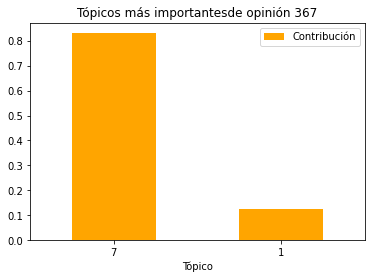

In [161]:
distribucion_topicos = pd.DataFrame({'Tópico': distribucion_indices,
                                     'Contribución': contribucion_distribucion})
distribucion_topicos.sort_values('Contribución', 
                                 ascending= False, inplace= True)
ax = distribucion_topicos.plot.bar(y= 'Contribución', x= 'Tópico', 
                                   rot= 0, color= "orange",
                                  title = 'Tópicos más importantes'
                                   'de opinión ' + str(indice_opinion))

In [162]:
print(texto_opinion['Comentario'], '\n')
for ind, topico in distribucion_topicos.iterrows():
    print("*** Tópico: " + str(int(topico.Tópico)) + " ***")
    palabras = [palabra[0] for palabra in lda_gensim.show_topic(
        topicid=int(topico.Tópico))]
    palabras = ', '.join(palabras)
    print(palabras, "\n")

Es maravilloso conocer un poco de nuestro México prehispánico, saber un poco más de la historia de nuestras raíces antes de la llegada de los españoles, y además en un ambiente tan cuidado, con tanto respeto y amor por nuestra cultura, enalteciendo siempre la grandeza de nuestros orígenes, sus facetas, y encontrarse además con danzantes en la entrada que dan al lugar un poco más de cercanía con la historia 

*** Tópico: 7 ***
histórico, experiencia, cultural, museo, encanto, disfrutar, cultura, falta, gusto, morelo 

*** Tópico: 1 ***
historia, méxico, museo, bello, recorrer, cultura, maravilloso, espectacular, recomendado, interactivo 



In [163]:
# Asignación de tópicos por documento
conteo = 0
for i, j in zip(lda_gensim[corpus][100:103], df_comentarios_antropologia['Comentario'][100:103]):
    print('Documento ' + str(conteo) + ': ', j, i, '\n')
    conteo += 1

Documento 0:  Exelente museo muy impresionante justo como lo recordaba un enorme placer pasar tiempo en un museo cómo está [(0, 0.3890558), (2, 0.32831714), (3, 0.012179905), (4, 0.01835704), (5, 0.019323451), (6, 0.0149341095), (8, 0.014331641), (9, 0.18654858)] 

Documento 1:  Uno de mis museos favoritos, si o si te llevas una experiencia bastante agradable y sobre todo muy interesante, muy estrictos con los lineamientos de sanidad de covid19 pero es totalmente recomendable ir a visitarlo. [(2, 0.010316896), (4, 0.01354323), (5, 0.013832729), (6, 0.010770005), (7, 0.5333236), (8, 0.38914862)] 

Documento 2:  Está hermoso, lleno de cultura, las raíces de nuestro México,  es muy grande, terminas agotado pero vale la pena visitarlo [(0, 0.010259755), (2, 0.013030182), (3, 0.011102676), (4, 0.016645169), (5, 0.5422756), (6, 0.013566854), (8, 0.27175295), (9, 0.105907105)] 



In [164]:
coherencia_modelo_lda = CoherenceModel(model= lda_gensim, texts= lista_tokens, dictionary= diccionario, coherence= 'c_v')
coherencia_lda = coherencia_modelo_lda.get_coherence()
print('Puntaje de coherencia: ', coherencia_lda)

Puntaje de coherencia:  0.3578792160524421


In [ ]:
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(topic_model= lda_gensim, corpus= corpus, dictionary= diccionario)
p

### Prueba de modelo con entradas diferentes

In [48]:
textos = df_comentarios_esp['Texto limpio'].tolist()
docs = list(nlp_es.pipe(texts= textos))

In [49]:
nueva_lista_tokens = []

In [50]:
for tokens in docs:
    tokens = list(tokens)
    nueva_lista_tokens.append([t.lemma_ for t in tokens])

In [51]:
df_comentarios_esp['Tokens'] = nueva_lista_tokens
df_comentarios_esp

,Comentario,Texto limpio,Tokens
0,Espectacular. Es una actividad para niños y gr...,espectacular actividad niños lleno personajes ...,"[espectacular, actividad, niño, lleno, persona..."
1,Super divertodo cada vez que vengo me divirto ...,super divertodo vengo divirto niña puedes toma...,"[super, divertodo, venir, divirto, niña, poder..."
2,"Un museo que vale mucho la pena, recomiendo po...",museo vale pena recomiendo disfrutarlo dividid...,"[museo, valer, pena, recomeir, disfrutar él, d..."
3,Me encantó la experiencia son 3 museos y tiene...,encantó experiencia museos atracción ta dimens...,"[encantar, experiencia, museo, atracción, ta, ..."
4,"Me encanto,tiene muchas celebridades, muy real...",encantotiene celebridades reales sitio diverti...,"[encantotienir, celebridad, real, sitio, diver..."
...,...,...,...
4163,"Muy buen destino, para local como para los tur...",destino local turistas lugaresel café excelente,"[destino, local, turistas, lugaresel, café, ex..."
4164,De las mejores experiencias en tours de café. ...,mejores experiencias tours café recomndadísimo...,"[mejor, experiencia, tours, café, recomndadísi..."
4165,Un lugar muy recomendable para conocer más sob...,recomendable café producido veracruz,"[recomendable, café, producido, veracruz]"
4166,"Excelente atención, la explicación de los cola...",excelente atención explicación colaboradores s...,"[excelente, atención, explicación, colaborador..."


In [90]:
bow_opinion_nueva = diccionario.doc2bow(df_comentarios_antropologia['Tokens'][99])

In [91]:
distribucion_indices = [topico[0] for topico in lda_gensim[bow_opinion_nueva]]
contribucion_distribucion = [topico[1] for topico in lda_gensim[bow_opinion_nueva]]

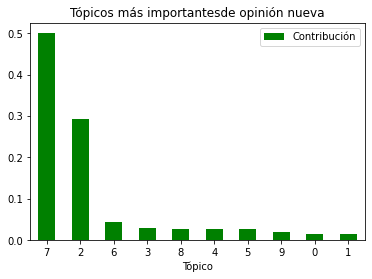

In [92]:
distribucion_topicos = pd.DataFrame({'Tópico': distribucion_indices,
                                     'Contribución': contribucion_distribucion})
distribucion_topicos.sort_values('Contribución', 
                                 ascending= False, inplace= True)
ax = distribucion_topicos.plot.bar(y= 'Contribución', x= 'Tópico', 
                                   rot= 0, color= "green",
                                  title = 'Tópicos más importantes'
                                   'de opinión nueva')

In [93]:
print(df_comentarios_antropologia['Comentario'][99], '\n')
for ind, topico in distribucion_topicos.iterrows():
    print("*** Tópico: " + str(int(topico.Tópico)) + " ***")
    palabras = [palabra[0] for palabra in lda_gensim.show_topic(
        topicid=int(topico.Tópico))]
    palabras = ', '.join(palabras)
    print(palabras, "\n")

Excelente sitio para revivir el pasado. Muy recomendado! 

*** Tópico: 7 ***
maya, historia, cultura, museo, zona, cancún, recorrido, lleno, excelente, hotelero 

*** Tópico: 2 ***
museo, exposición, puebla, visto, valer, pena, terraza, arte, ciudad, moderno 

*** Tópico: 6 ***
bonito, museo, interesante, sala, pieza, limpio, recorrido, encantar, exposición, interactivo 

*** Tópico: 3 ***
museo, recomeir, parque, recorrido, bonito, naturaleza, ruina, libre, excelente, padre 

*** Tópico: 8 ***
personal, amable, exposición, museo, excelente, atención, lindo, super, interesante, tomar 

*** Tópico: 4 ***
excelente, visitar, familia, pasar, historia, cultura, museo, agradable, aprender, disfrutar 

*** Tópico: 5 ***
maya, cultura, museo, excelente, exposición, interesante, información, pieza, san, permanente 

*** Tópico: 9 ***
domingo, entrada, gratis, gratuito, mexicano, pesos, costo, acceso, cafetería, estudiante 

*** Tópico: 0 ***
actividad, vegetación, pequeño, hermoso, conocer, at

In [94]:
lda_gensim.save('DatosAnálisisSentimientosAspectos/modelo_museos.model')
diccionario.save('DatosAnálisisSentimientosAspectos/museos.dictionary')

## Visualización de tópicos con pyLDAVIS

In [95]:
coherencia_modelo_lda = CoherenceModel(model= lda_gensim, texts= lista_tokens, dictionary= diccionario, coherence= 'c_v')
coherencia_lda = coherencia_modelo_lda.get_coherence()
print('Puntaje de coherencia: ', coherencia_lda)

Puntaje de coherencia:  0.40268763698135207


In [ ]:
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(topic_model= lda_gensim, corpus= corpus, dictionary= diccionario)
p

c:\users\jedua\documents\i+d+i\i+d+i\lib\site-packages\pyLDAvis\_prepare.py:246: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  default_term_info = default_term_info.sort_values(


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.088951  0.010344       1        1  24.761286
6      0.061554 -0.047663       2        1  13.980282
7      0.066245 -0.153742       3        1  10.283785
3      0.020935  0.079433       4        1   9.637340
8      0.123439  0.117443       5        1   9.280688
5      0.151058 -0.167279       6        1   9.163251
4      0.003998  0.003048       7        1   7.956410
9     -0.004693  0.261478       8        1   7.177523
1     -0.238666 -0.163819       9        1   3.946430
0     -0.272823  0.060757      10        1   3.813004, topic_info=              Term        Freq       Total Category  logprob  loglift
1534          maya  875.000000  875.000000  Default  30.0000  30.0000
103           zona  478.000000  478.000000  Default  29.0000  29.0000
161   arqueológico  405.000000  405.000000  Default  28.0000  28.0000
107         bonito  662.000000  662.000000  Default  27.0000  27.0000
28         cultura  805.000000  805.000000  Default  26.0000  26.0000
...            ...         ...         ...      ...      ...      ...
553         animal   23.049894  128.194701  Topic10  -4.5064   1.5509
186     exhibición   25.104225  185.289803  Topic10  -4.4210   1.2679
279      agradable   16.142056  218.105173  Topic10  -4.8626   0.6632
510        culturo   14.214942   74.605015  Topic10  -4.9897   1.6088
587    recomendado   14.014862   85.507329  Topic10  -5.0039   1.4583

[591 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
156       3  0.527966   abierto
156       4  0.199771   abierto
156       5  0.185502   abierto
156       8  0.085616   abierto
890       3  0.935461  aburrido
...     ...       ...       ...
178       3  0.516816      área
178       4  0.078305      área
178       5  0.336714      área
389       1  0.407081     época
389       3  0.584072     época

[942 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 7, 8, 4, 9, 6, 5, 10, 2, 1])

### LDA con Sklearn
Mediante el modelado de tópicos, se busca conocer las relaciones semánticas en cada opinión sobre el museo, para así identificar los aspectos que determinan la preferencia (o aversión) del usuario. En este caso, se utilizará el modelo más común, el LDA (Latent Dirichlet Allocation), para obtener los tópicos y sus respectivas frecuencias en cada documento.

In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

In [58]:
vectorizador_tf_idf = TfidfVectorizer(tokenizer= lambda doc: doc, lowercase=False)
vectorizador_cv = CountVectorizer(tokenizer= lambda doc: doc, lowercase=False)

In [59]:
lista_tf_idf = vectorizador_tf_idf.fit_transform(lista_tokens)
lista_cv = vectorizador_cv.fit_transform(lista_tokens)

In [60]:
lista_tf_idf

<4948x6727 sparse matrix of type '<class 'numpy.float64'>'
	with 55793 stored elements in Compressed Sparse Row format>

In [61]:
lista_cv

<4948x6727 sparse matrix of type '<class 'numpy.int64'>'
	with 55793 stored elements in Compressed Sparse Row format>

In [62]:
vocabulario_tf_idf = vectorizador_tf_idf.get_feature_names()
print(len(vocabulario_tf_idf))
vocabulario_cv = vectorizador_cv.get_feature_names()
print(len(vocabulario_cv))

6727
6727


c:\users\jedua\documents\i+d+i\i+d+i\lib\site-packages\sklearn\utils\deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


In [63]:
# Implementación de LDA
lda_sklearn = LatentDirichletAllocation(n_components= 10, max_iter= 10, random_state= 42)
x_topicos = lda_sklearn.fit_transform(lista_tf_idf)
palabras_topicos = lda_sklearn.components_

In [64]:
num_palabras = 5
for i, dist_topico in enumerate(palabras_topicos):
    dist_topicos_ord = np.argsort(dist_topico)
    palabras_topicos = np.array(vocabulario_tf_idf)[dist_topicos_ord]
    palabras_topicos = palabras_topicos[:-num_palabras:-1]
    print('Tópico', str(i+1), palabras_topicos)

Tópico 1 ['terraza' 'cerrado' 'museo' 'espectacular']
Tópico 2 ['museo' 'exposición' 'excelente' 'sala']
Tópico 3 ['interesante' 'museo' 'hermoso' 'maya']
Tópico 4 ['excelente' 'familia' 'bonito' 'historia']
Tópico 5 ['museo' 'organizado' 'seguridad' 'cuidado']
Tópico 6 ['museo' 'pequeño' 'zona' 'arqueológico']
Tópico 7 ['valer' 'pena' 'museo' 'lindo']
Tópico 8 ['increíble' 'museo' 'interesante' 'imperdible']
Tópico 9 ['museo' 'cultura' 'maya' 'visita']
Tópico 10 ['museo' 'domingo' 'excelente' 'maravilloso']


In [65]:
# Asignación de tópicos por documento
topicos_doc = lda_sklearn.transform(lista_tf_idf[:3])
for i in range(topicos_doc.shape[0]):
    topico_doc = topicos_doc[i].argmax()
    print('Documento', i + 1, '->', df_comentarios_arqueologia['Comentario'][i], 'Tópico: ', topico_doc, '\n')  

Documento 1 -> Un sitio muy hermoso en medio de la ciudad. Me encantó la organización de las salas del museo y la continuidad que le dan a la historia del antiguo imperio azteca, acomodadas de una gran variedad de piezas únicas. Me hubiera gustado que el establecimiento tuvieron algún servicio de guia e instrucción. Un punto a considerar para el visitante es que algunas salas tienen restringido el acceso. Y estudiantes tienen acceso gratis. Tópico:  8 

Documento 2 -> Una extraordinaria experiencia que permite echar un vistazo a la magestuosidad de la cultura mexica gracias al gran trabajo de los que participaron y aun participan en el proyecto del templo mayor. Han incluido presentaciones multimedia que muestran detalles  de las batallas entre mexicas y las fuerzas invasoras junto con sus aliados locales. Una visita que no puede faltar al turista nacional ni extranjero. Tópico:  9 

Documento 3 -> Un museo realizado sobre las ruinas de lo qué desea qué recordemos. Nuestros orígenes.
T

# Elaborar una lista con adjetivos positivos y negativos para asignar valores automáticos con vocab
if token in lista_positivos:
    nlp_es.vocab[token].sentiment = 1
    
    ## https://neptune.ai/blog/pyldavis-topic-modelling-exploration-tool-that-every-nlp-data-scientist-should-know

## https://elmundodelosdatos.com/topic-modeling-gensim-asignacion-topicos/

## Asignar temas concretos a las palabras de los tópicos

# **Tarea de extracción de adjetivos**

In [78]:
from collections import Counter

In [68]:
df_comentarios_limpios_antropologia = pd.read_csv('Datos/comentarios_museos_antropología_tópicos.csv', index_col= 0)
df_comentarios_limpios_antropologia

,Comentario,Texto limpio
0,Excelente lugar lleno de conocimiento y cultur...,excelente lleno conocimiento cultura bases cie...
1,"Extraordinario, sin duda se gana ser el museo ...",extraordinario duda gana museo importante méxi...
2,"Un museo lleno de historia, muy bello. Se expo...",museo lleno historia bello exponen cantidad ob...
3,El lugar indicado para conocer sobre nuestra c...,indicado cultura visite viernes personas recor...
4,Necesitas de más de dos horas para recorrer la...,necesitas recorrer instalaciones permiten entr...
...,...,...
4390,Encantador,encantador
4391,¡Hora de tocar el piano!,hora tocar piano
4392,chidin chidon,chidin chidon
4393,Fascinante y educativo.,fascinante educativo


In [69]:
df_comentarios_limpios_antropologia.dropna(inplace= True)
df_comentarios_limpios_antropologia.reset_index(inplace= True)
df_comentarios_limpios_antropologia.drop(columns= 'index', inplace= True)
df_comentarios_limpios_antropologia

,Comentario,Texto limpio
0,Excelente lugar lleno de conocimiento y cultur...,excelente lleno conocimiento cultura bases cie...
1,"Extraordinario, sin duda se gana ser el museo ...",extraordinario duda gana museo importante méxi...
2,"Un museo lleno de historia, muy bello. Se expo...",museo lleno historia bello exponen cantidad ob...
3,El lugar indicado para conocer sobre nuestra c...,indicado cultura visite viernes personas recor...
4,Necesitas de más de dos horas para recorrer la...,necesitas recorrer instalaciones permiten entr...
...,...,...
4364,Museo Arqueológico.,museo arqueológico
4365,Encantador,encantador
4366,¡Hora de tocar el piano!,hora tocar piano
4367,chidin chidon,chidin chidon


In [70]:
textos = df_comentarios_limpios_antropologia['Texto limpio']
docs = list(nlp_es.pipe(texts= textos))

In [75]:
lista_adjetivos_antropologia = []

In [76]:
for tokens in docs:
    for t in tokens:
        if t.pos_ == 'ADJ':
            lista_adjetivos_antropologia.append(t.text)

In [87]:
frecuencia_palabras = Counter(lista_adjetivos_antropologia)
print(frecuencia_palabras.most_common(n= 30))

[('excelente', 633), ('interesante', 365), ('bonito', 323), ('hermoso', 255), ('recomendable', 160), ('historia', 149), ('agradable', 129), ('increíble', 122), ('lleno', 120), ('cerrado', 119), ('personal', 116), ('grande', 113), ('mexicana', 111), ('histórico', 111), ('completo', 100), ('temporales', 98), ('impresionante', 97), ('mejores', 97), ('interesantes', 92), ('domingos', 84), ('limpio', 78), ('cultural', 76), ('gratuita', 72), ('amable', 70), ('entrada', 67), ('maravilloso', 66), ('genial', 64), ('recomendado', 63), ('obligada', 63), ('importante', 59)]


In [88]:
palabra = []
frecuencia = []

In [89]:
for i in frecuencia_palabras.most_common(n= 30):
    palabra.append(i[0])
    frecuencia.append(i[1])

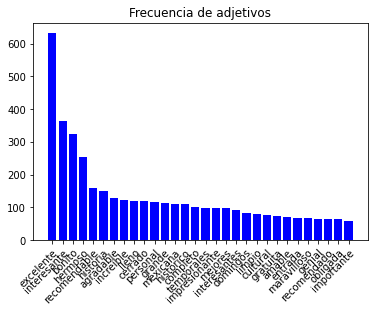

In [145]:
plt.bar(palabra, frecuencia, color= 'blue')
plt.xticks(range(len(palabra)), palabra, rotation= 45, ha= 'right', rotation_mode= 'anchor')
plt.title('Frecuencia de adjetivos')
plt.savefig('Figuras/Fig_diez.jpg', dpi= 360, bbox_inches= 'tight')
plt.show()

In [148]:
df_comentarios_limpios_arqueologia = pd.read_csv('Datos/comentarios_museos_arqueología_tópicos.csv', index_col= 0)
df_comentarios_limpios_arqueologia

,Comentario,Texto limpio
0,Un sitio muy hermoso en medio de la ciudad. Me...,sitio hermoso ciudad encantó organización sala...
1,Una extraordinaria experiencia que permite ech...,extraordinaria experiencia permite echar vista...
2,Un museo realizado sobre las ruinas de lo qué ...,museo ruinas desea recordemos orígenes forma u...
3,"Excelente, si tienes credencial de estudiante ...",excelente credencial estudiante entras gratis ...
4,un tesoro en el corazon de la ciudad. De las m...,tesoro corazon ciudad mil razones visitar ciud...
...,...,...
4943,Excelente lugar para conocer mas sobre la cult...,excelente cultura maya
4944,"Hermoso museo, es un paseo muy interesante.",hermoso museo paseo interesante
4945,Zona arqueologica San Miguelito,zona arqueologica san miguelito
4946,Increible,increible


In [150]:
df_comentarios_limpios_arqueologia.dropna(inplace= True)
df_comentarios_limpios_arqueologia.reset_index(inplace= True)
df_comentarios_limpios_arqueologia.drop(columns= 'index', inplace= True)
df_comentarios_limpios_arqueologia

,Comentario,Texto limpio
0,Un sitio muy hermoso en medio de la ciudad. Me...,sitio hermoso ciudad encantó organización sala...
1,Una extraordinaria experiencia que permite ech...,extraordinaria experiencia permite echar vista...
2,Un museo realizado sobre las ruinas de lo qué ...,museo ruinas desea recordemos orígenes forma u...
3,"Excelente, si tienes credencial de estudiante ...",excelente credencial estudiante entras gratis ...
4,un tesoro en el corazon de la ciudad. De las m...,tesoro corazon ciudad mil razones visitar ciud...
...,...,...
4935,Excelente lugar para conocer mas sobre la cult...,excelente cultura maya
4936,"Hermoso museo, es un paseo muy interesante.",hermoso museo paseo interesante
4937,Zona arqueologica San Miguelito,zona arqueologica san miguelito
4938,Increible,increible


In [151]:
textos = df_comentarios_limpios_arqueologia['Texto limpio']
docs = list(nlp_es.pipe(texts= textos))

In [152]:
lista_adjetivos_arqueologia = []

In [153]:
for tokens in docs:
    for t in tokens:
        if t.pos_ == 'ADJ':
            lista_adjetivos_arqueologia.append(t.text)

In [154]:
frecuencia_palabras = Counter(lista_adjetivos_arqueologia)
print(frecuencia_palabras.most_common(n= 30))

[('excelente', 886), ('maya', 626), ('bonito', 526), ('interesante', 437), ('hermoso', 331), ('personal', 231), ('vista', 231), ('arqueológica', 212), ('agradable', 211), ('recomendable', 202), ('increíble', 201), ('interesantes', 168), ('grande', 159), ('mayas', 153), ('amable', 143), ('pequeño', 139), ('limpio', 135), ('impresionante', 121), ('mejores', 120), ('moderno', 116), ('temporales', 111), ('domingos', 106), ('lleno', 105), ('historia', 99), ('hermosa', 97), ('arqueológicas', 96), ('entrada', 95), ('cultural', 95), ('maravilloso', 94), ('completo', 93)]


In [155]:
palabra = []
frecuencia = []

In [156]:
for i in frecuencia_palabras.most_common(n= 30):
    palabra.append(i[0])
    frecuencia.append(i[1])

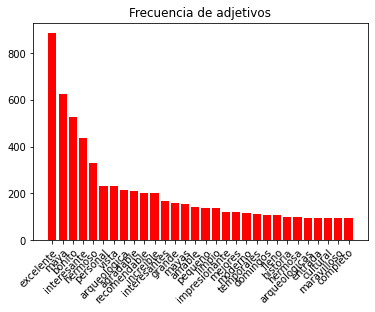

In [157]:
plt.bar(palabra, frecuencia, color= 'red')
plt.xticks(range(len(palabra)), palabra, rotation= 45, ha= 'right', rotation_mode= 'anchor')
plt.title('Frecuencia de adjetivos')
plt.savefig('Figuras/Fig_diez.jpg', dpi= 360, bbox_inches= 'tight')
plt.show()

# **Cambio de sección**

In [19]:
textos = df_comentarios_antropologia['Comentario'].tolist()
docs = list(nlp_es.pipe(texts= textos))

In [20]:
spacy.explain('advcl')

'adverbial clause modifier'

In [22]:
for tokens in docs:
    for t in tokens:
        if t.pos_ == 'ADJ':
            #print(t.text, t.pos_, t.dep_)
            pass

In [55]:
doc = nlp_es(df_comentarios_antropologia['Comentario'][0])
doc

Excelente lugar lleno de conocimiento y cultura con bases científicas, excelente para entender el desarrollo humano y en algunas salas específicamente tiempos más recientes. Todo es muy interesante vale la pena venir con familia. Fui en domingo y no cobran entrada( piden INE) solo a extranjeros es una exelente medida para no limitar el conocimiento.

In [61]:
stemmer = SnowballStemmer('spanish')

In [62]:
for t in df_comentarios_antropologia['Texto limpio'][0]:
    print(stemmer.stem(t))

excelent
llen
conoc
cultur
bas
cientif
excelent
entend
desarroll
human
sal
especif
tiemp
recient
interes
val
pen
ven
famili
doming
cobr
entrad
pid
ine
extranjer
exelent
med
limit
conoc


In [56]:
for token in doc:
    if token.pos_ == 'ADJ': #and token.pos_ == 'NOUN':
        print(token.text.upper(), token.is_stop, token.is_punct, token.pos_, token.dep_, token.sentiment)

RECOMENDADO False False ADJ amod 0.0


In [52]:
nlp_es.vocab['excelente'].sentiment = 0.9

In [52]:
displacy.render(doc, style= 'dep')

In [202]:
lista = []

In [203]:
for token in df_comentarios_antropologia['Comentario'][0].split():
    #if token.lower() not in nlp_es.Defaults.stop_words and token.lower() not in stopwords.words('spanish'):
    if token.lower() not in palabras_parada:
        lista.append(token)

In [204]:
print('--> Texto con palabras de parada: ', df_comentarios_antropologia['Comentario'][0])
print('--> Texto sin palabras de parada: ', ' '.join(lista))

--> Texto con palabras de parada:  Excelente lugar lleno de conocimiento y cultura con bases científicas, excelente para entender el desarrollo humano y en algunas salas específicamente tiempos más recientes. Todo es muy interesante vale la pena venir con familia. Fui en domingo y no cobran entrada( piden INE) solo a extranjeros es una exelente medida para no limitar el conocimiento.
--> Texto sin palabras de parada:  Excelente lleno conocimiento cultura bases científicas, excelente entender desarrollo humano salas específicamente tiempos recientes. interesante vale pena venir familia. domingo cobran entrada( piden INE) extranjeros exelente medida limitar conocimiento.


In [208]:
for token in doc:
    if not token.is_punct and not token.is_stop:
        print(token.text)
    #print(token.text, token.is_stop, token.is_punct, token.lemma_)

Excelente
lleno
conocimiento
y
cultura
bases
científicas
excelente
entender
desarrollo
humano
y
salas
específicamente
tiempos
recientes
interesante
vale
pena
venir
familia
domingo
y
cobran
entrada
piden
INE
a
extranjeros
exelente
medida
limitar
conocimiento


In [49]:
textos = df_comentarios_cyt['Comentario'].tolist()

In [50]:
docs = list(nlp_es.pipe(texts= textos))

In [59]:
docs[0]

Que decir;  impresionante museo necesitas el tiempo suficiente para recorrerlo todo pues es muy extenso. Cuenta con diversas exposiciones y salas;  La Química en Todo; Física; El Cerebro... Los Océanos; Tesoros fósiles.

La admisión general tiene un costo de $90 pesos y las exposiciones adicionales cuentan con costo de $15 pesos (Océanos) $30 pesos (Fósiles).

El costo del estacionamiento es de $15 pesos.

Tiene un área pequeña de juegos para los niños en la parte exterior.

Es un museo imperdible.

In [121]:
for t in docs[0]:
    if not t.is_punct and not t.is_stop and not t.is_digit and t.is_alpha and not t.pos_ == 'CCONJ':
        print(t.text, t.pos_)

impresionante ADJ
museo NOUN
necesitas VERB
suficiente ADJ
recorrerlo VERB
extenso ADJ
diversas DET
exposiciones NOUN
salas NOUN
Química PROPN
Física PROPN
Cerebro PROPN
Océanos PROPN
Tesoros PROPN
fósiles ADJ
admisión NOUN
costo NOUN
pesos NOUN
exposiciones NOUN
adicionales ADJ
cuentan VERB
costo NOUN
pesos NOUN
Océanos PROPN
pesos NOUN
Fósiles PROPN
costo NOUN
estacionamiento NOUN
pesos NOUN
área NOUN
pequeña ADJ
juegos PROPN
niños NOUN
exterior ADJ
museo NOUN
imperdible ADJ
